# 🔍 Feature Analysis Report

This report presents a comprehensive feature analysis for the binary classification task (label: `probe`). The goal is to understand feature relevance, interactions, redundancy, and their relationship with the target.

---

## 📊 1. Correlation Matrix
- **Objective**: Examine linear relationships between features and detect multicollinearity.
- **Deliverables**:
  - Heatmap of feature-to-feature correlations
  - Correlation of each feature with the target label (`probe`)

---

## 🌲 2. Feature Importance (Tree-Based Models)
- **Objective**: Identify key features based on their contribution to model performance.
- **Approach**:
  - Train a Random Forest / XGBoost model
  - Extract and rank `.feature_importances_`
- **Deliverables**:
  - Bar plot showing relative importance of features

---

## 🧠 3. SHAP (SHapley Additive ExPlanations)
- **Objective**: Interpret model predictions and understand feature impact direction and magnitude.
- **Deliverables**:
  - SHAP summary plot (global feature influence)
  - SHAP dependence plots for top features

---

## 📈 4. Mutual Information
- **Objective**: Capture non-linear relationships between each feature and the target.
- **Deliverables**:
  - Ranked bar chart of features based on mutual information score

---

## 🧪 5. Univariate Feature Selection
- **Objective**: Assess feature significance via statistical tests.
- **Approach**:
  - Use `SelectKBest` with:
    - ANOVA F-value (`f_classif`)
    - Chi-squared (`chi2`) if applicable
- **Deliverables**:
  - Ranked list of features by statistical significance

---

## 🧮 6. Variance Inflation Factor (VIF)
- **Objective**: Detect multicollinearity and redundant features.
- **Deliverables**:
  - Table showing VIF scores for all features
  - Identification of high-VIF (correlated) features

---

## 🔁 7. Recursive Feature Elimination (RFE)
- **Objective**: Select optimal feature subset by recursively eliminating the least important ones.
- **Approach**:
  - Use Logistic Regression or Tree-based estimator
- **Deliverables**:
  - Ranked list of selected features
  - Optimal feature count vs model performance plot (optional)

---

## 🧭 8. PCA / UMAP (Optional Visualization)
- **Objective**: Visualize data structure and separability in reduced dimensions.
- **Approach**:
  - Apply PCA and/or UMAP
  - Plot 2D scatter with points colored by target (`probe`)
- **Deliverables**:
  - 2D scatter plot showing class distribution

---

> 💡 This analysis is foundational for feature selection, model interpretation, and improving generalization performance in the binary classification task.



In [3]:
import pandas as pd


# df=pd.read_csv("/home/rounak/CODE/Low_Engagement_Detection/Data_preprocess/Merge_Eye+Physio/merged_output.csv")
df=pd.read_csv("/home/rounak/CODE/Low_Engagement_Detection/Data_preprocess/Final_Data_Table/merged_all.csv")

print(df.shape)

(1996, 49)


In [38]:
print(df.columns)

Index(['GSR_mean', 'GSR_variance', 'HR_mean', 'HR_variance',
       '75_percentile_GSR', '75_percentile_HR', 'GSRmean_persen_diff',
       'HRmean_persent_diff', 'GSRmean_diff', 'HRmean_diff',
       'valence_acc_video', 'arousal_acc_video', 'Score', 'valence', 'arousal',
       'probe', 'prev_window', 'num_samples', 'pupil_diameter_mean',
       'pupil_diameter_std', 'diameter_3d_mean', 'diameter_3d_std',
       'sphere_radius_mean', 'circle_3d_radius_mean', 'ellipse_axis_a_mean',
       'ellipse_axis_b_mean', 'ellipse_angle_mean', 'ellipse_angle_std',
       'confidence_x_mean', 'confidence_y_mean', 'confidence_x_std',
       'confidence_y_std', 'blink_count', 'gaze_movement_mean',
       'gaze_movement_std', 'gaze_dir_variability', 'eye_center_movement_mean',
       'eye_center_movement_std', 'missing_value_ratio'],
      dtype='object')


In [69]:
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes.value_counts())
print("\nMissing values per column:\n", df.isnull().sum().sort_values(ascending=False))


Shape of dataset: (1996, 39)

Data types:
 float64    39
Name: count, dtype: int64

Missing values per column:
 Score                       64
GSR_variance                 0
GSR_mean                     0
HR_variance                  0
75_percentile_GSR            0
75_percentile_HR             0
HR_mean                      0
GSRmean_persen_diff          0
HRmean_persent_diff          0
HRmean_diff                  0
GSRmean_diff                 0
valence_acc_video            0
arousal_acc_video            0
valence                      0
arousal                      0
probe                        0
prev_window                  0
num_samples                  0
pupil_diameter_mean          0
pupil_diameter_std           0
diameter_3d_mean             0
diameter_3d_std              0
sphere_radius_mean           0
circle_3d_radius_mean        0
ellipse_axis_a_mean          0
ellipse_axis_b_mean          0
ellipse_angle_mean           0
ellipse_angle_std            0
confidence_x_mean   

probe
0.0    66.933868
1.0    33.066132
Name: proportion, dtype: float64


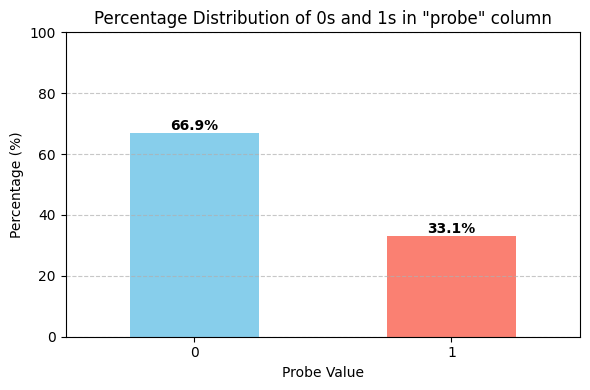

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate percentage of each class
value_counts = df['probe'].value_counts(normalize=True).sort_index() * 100
print(value_counts)

# Plotting
plt.figure(figsize=(6, 4))
value_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Percentage Distribution of 0s and 1s in "probe" column')
plt.xlabel('Probe Value')
plt.ylabel('Percentage (%)')
plt.xticks([0, 1], ['0', '1'], rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate the bars with percentage values
for i, value in enumerate(value_counts):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


Class distribution of 'probe':
 probe
0.0    0.669339
1.0    0.330661
Name: proportion, dtype: float64


<Axes: title={'center': 'Class Distribution of probe'}, xlabel='probe'>

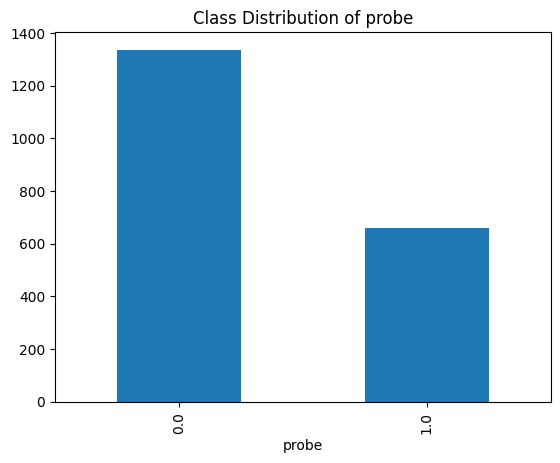

In [70]:
print("Class distribution of 'probe':\n", df['probe'].value_counts(normalize=True))
df['probe'].value_counts().plot(kind='bar', title='Class Distribution of probe')


In [71]:
df.describe().T[['mean', 'std', 'min', 'max']]


,mean,std,min,max
GSR_mean,5.821681e-01,2.372530e-01,0.048793,9.409483e-01
GSR_variance,1.281193e-03,2.410487e-03,0.000015,5.033424e-02
HR_mean,4.017386e-01,1.065046e-01,0.244468,5.742857e-01
HR_variance,6.237933e-03,8.048723e-03,0.000005,5.209067e-02
75_percentile_GSR,6.046805e-01,2.419116e-01,0.064655,9.784483e-01
75_percentile_HR,4.265818e-01,1.187738e-01,0.244681,7.023810e-01
GSRmean_persen_diff,1.456894e-01,1.512146e-01,0.000143,7.741858e-01
HRmean_persent_diff,7.250751e-02,9.757601e-02,0.000010,2.501972e-01
GSRmean_diff,1.456894e-01,1.512146e-01,0.000143,7.741858e-01
HRmean_diff,7.250751e-02,9.757601e-02,0.000010,2.501972e-01


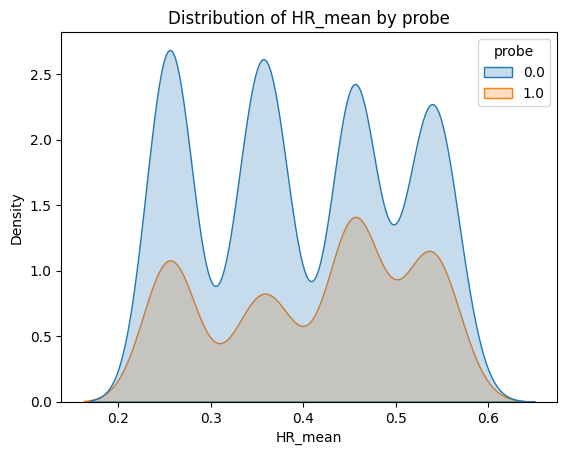

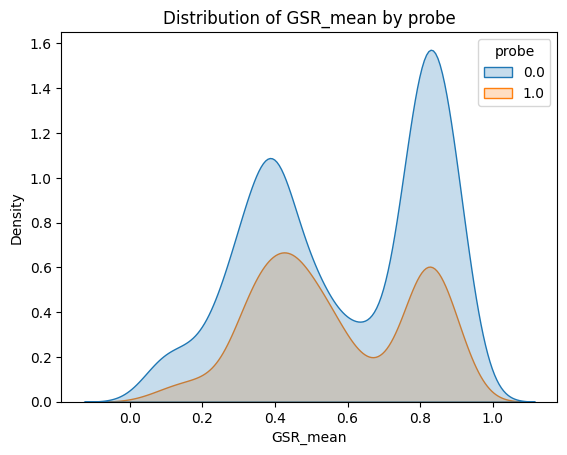

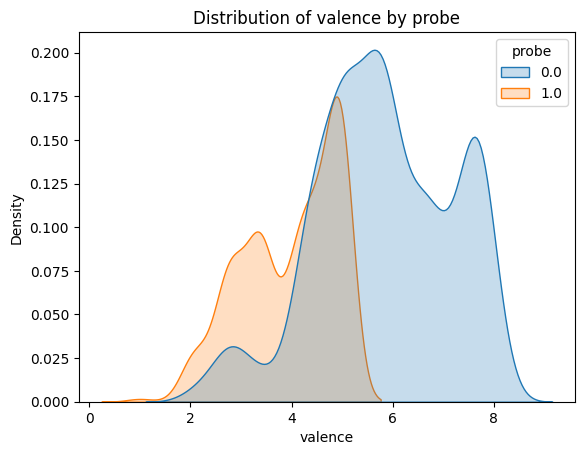

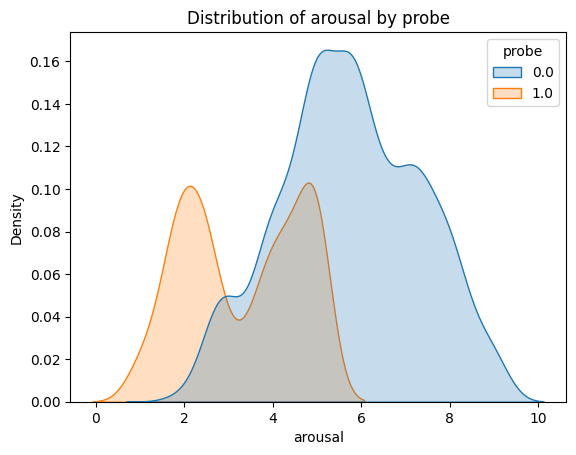

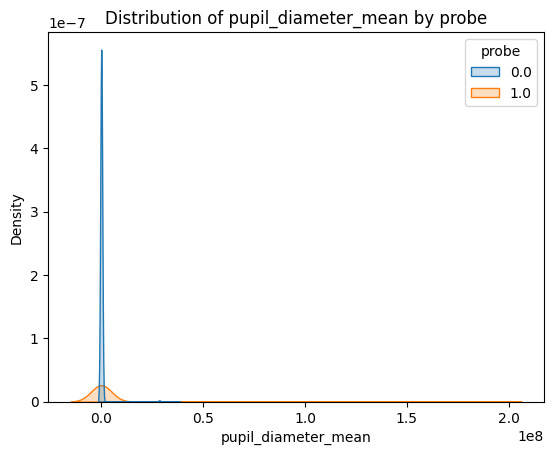

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

features_to_plot = ['HR_mean', 'GSR_mean', 'valence', 'arousal', 'pupil_diameter_mean']  # You can expand this
for feature in features_to_plot:
    sns.kdeplot(data=df, x=feature, hue='probe', fill=True)
    plt.title(f'Distribution of {feature} by probe')
    plt.show()


probe
0.0    1336
1.0     660
Name: count, dtype: int64


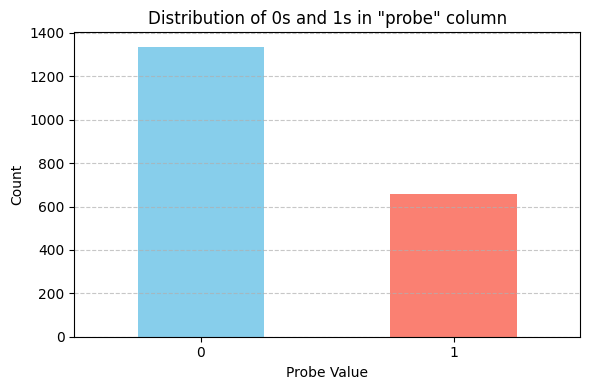

In [73]:
#Number of 0s and 1s
import pandas as pd
import matplotlib.pyplot as plt

# Count occurrences of 0s and 1s
value_counts = df['probe'].value_counts().sort_index()
print(value_counts)
# Plotting
plt.figure(figsize=(6, 4))
value_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of 0s and 1s in "probe" column')
plt.xlabel('Probe Value')
plt.ylabel('Count')
plt.xticks([0, 1], ['0', '1'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [2]:
df.head()

,GSR_mean,GSR_variance,HR_mean,HR_variance,75_percentile_GSR,75_percentile_HR,GSRmean_persen_diff,HRmean_persent_diff,GSRmean_diff,HRmean_diff,...,confidence_y_std,blink_count,gaze_movement_mean,gaze_movement_std,gaze_dir_variability,eye_center_movement_mean,eye_center_movement_std,missing_value_ratio,start_time_ms,end_time_ms
0,0.425789,0.003011,0.259574,0.001005,0.473684,0.265957,0.267649,0.235091,0.267649,0.235091,...,0.138880,93.0,45.327137,143.357001,0.099878,1.982644,8.853739,0.048079,1.752928e+12,1.752928e+12
1,0.425789,0.003011,0.259574,0.001005,0.473684,0.265957,0.267649,0.235091,0.267649,0.235091,...,0.053328,7.0,4.436910,22.834216,0.053657,0.139038,2.393078,0.018506,1.752928e+12,1.752928e+12
2,0.425263,0.002531,0.257660,0.001056,0.447368,0.265957,0.268175,0.237006,0.268175,0.237006,...,0.053328,7.0,4.436910,22.834216,0.053657,0.139038,2.393078,0.018506,1.752928e+12,1.752928e+12
3,0.425263,0.002531,0.257660,0.001056,0.447368,0.265957,0.268175,0.237006,0.268175,0.237006,...,0.068934,16.0,7.792053,38.013178,0.088200,0.291830,3.464190,0.020819,1.752928e+12,1.752928e+12
4,0.517895,0.003336,0.248511,0.001411,0.552632,0.263298,0.175543,0.246155,0.175543,0.246155,...,0.053328,7.0,4.436910,22.834216,0.053657,0.139038,2.393078,0.018506,1.752928e+12,1.752928e+12


In [4]:
df.columns

Index(['GSR_mean', 'GSR_variance', 'HR_mean', 'HR_variance',
       '75_percentile_GSR', '75_percentile_HR', 'GSRmean_persen_diff',
       'HRmean_persent_diff', 'GSRmean_diff', 'HRmean_diff',
       'valence_acc_video', 'arousal_acc_video', 'P_id', 'video_id', 'Score',
       'time', 'valence', 'arousal', 'videoID', 'start_time', 'end_time',
       'probe', 'prev_window', 'start_time_sec', 'end_time_sec', 'num_samples',
       'pupil_diameter_mean', 'pupil_diameter_std', 'diameter_3d_mean',
       'diameter_3d_std', 'sphere_radius_mean', 'circle_3d_radius_mean',
       'ellipse_axis_a_mean', 'ellipse_axis_b_mean', 'ellipse_angle_mean',
       'ellipse_angle_std', 'confidence_x_mean', 'confidence_y_mean',
       'confidence_x_std', 'confidence_y_std', 'blink_count',
       'gaze_movement_mean', 'gaze_movement_std', 'gaze_dir_variability',
       'eye_center_movement_mean', 'eye_center_movement_std',
       'missing_value_ratio', 'start_time_ms', 'end_time_ms'],
      dtype='object')

In [40]:
drop_cols = ['start_time', 'start_time_sec', 'start_time_ms',
             'end_time', 'end_time_sec', 'end_time_ms', 'time']

# Also drop IDs and labels from feature set
drop_cols += ['P_id', 'video_id', 'videoID']  # if not meant as features

df = df.drop(columns=drop_cols, errors='ignore')

In [42]:
df.columns

Index(['GSR_mean', 'GSR_variance', 'HR_mean', 'HR_variance',
       '75_percentile_GSR', '75_percentile_HR', 'GSRmean_persen_diff',
       'HRmean_persent_diff', 'GSRmean_diff', 'HRmean_diff',
       'valence_acc_video', 'arousal_acc_video', 'Score', 'valence', 'arousal',
       'probe', 'prev_window', 'num_samples', 'pupil_diameter_mean',
       'pupil_diameter_std', 'diameter_3d_mean', 'diameter_3d_std',
       'sphere_radius_mean', 'circle_3d_radius_mean', 'ellipse_axis_a_mean',
       'ellipse_axis_b_mean', 'ellipse_angle_mean', 'ellipse_angle_std',
       'confidence_x_mean', 'confidence_y_mean', 'confidence_x_std',
       'confidence_y_std', 'blink_count', 'gaze_movement_mean',
       'gaze_movement_std', 'gaze_dir_variability', 'eye_center_movement_mean',
       'eye_center_movement_std', 'missing_value_ratio'],
      dtype='object')

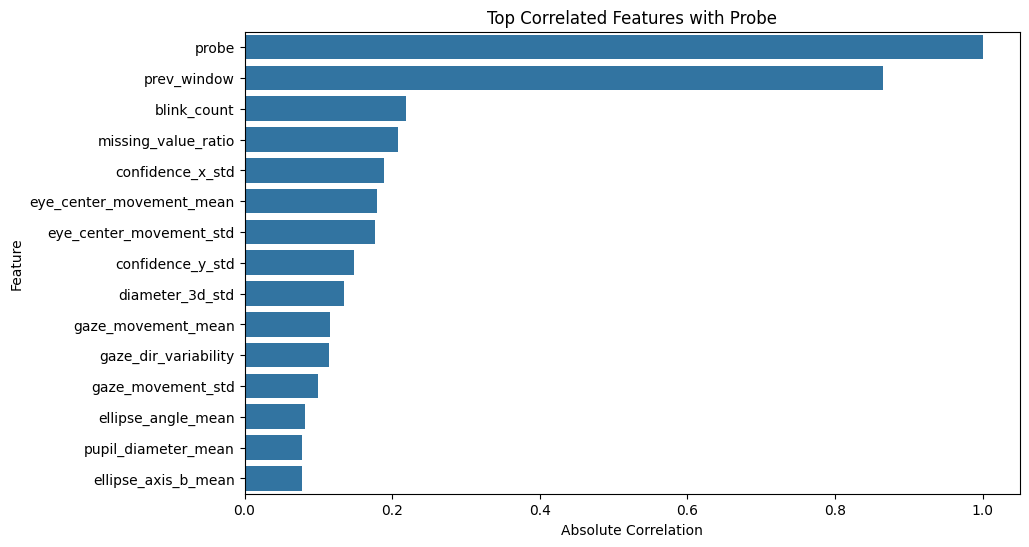

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt


# Compute correlations
corr = df.corr(numeric_only=True)

# Correlation with the label
label_corr = corr['probe'].sort_values(ascending=False)

# Plot top correlated features with 'probe'
plt.figure(figsize=(10, 6))
sns.barplot(x=label_corr.abs().head(15), y=label_corr.abs().head(15).index)
plt.title('Top Correlated Features with Probe')
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare data
X = df.drop(columns=['probe'])
y = df['probe']

# Optional: drop non-numeric or non-useful columns
X = X.select_dtypes(include=['number'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


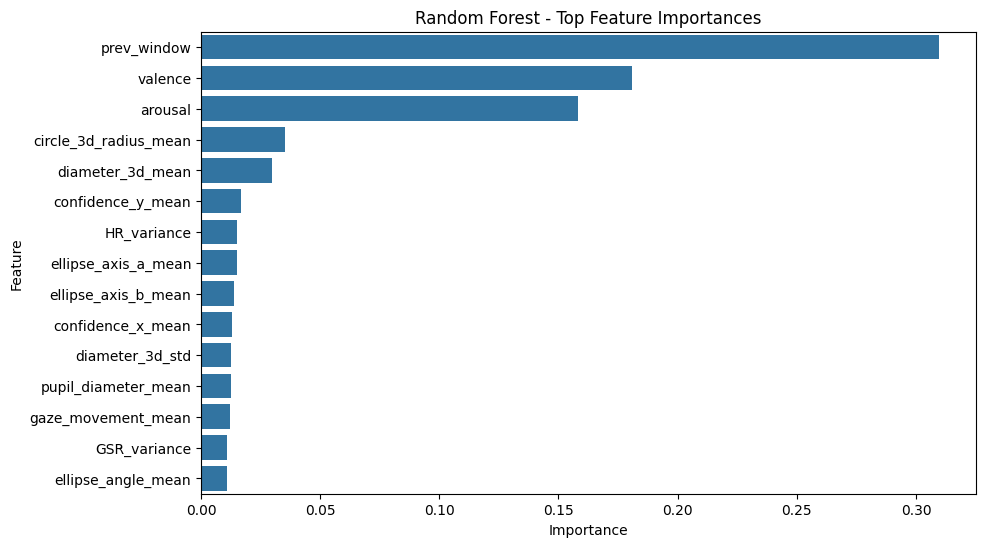

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# drop_cols = ['start_time', 'start_time_sec', 'start_time_ms',
#              'end_time', 'end_time_sec', 'end_time_ms', 'time']

# # Also drop IDs and labels from feature set
# drop_cols += ['P_id', 'video_id', 'videoID', 'probe']  # if not meant as features

# # Features only
# X = df.drop(columns=drop_cols, errors='ignore')
# y = df['probe']



# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(15), y=importances.head(15).index)
plt.title("Random Forest - Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [6]:
missing = X.isnull().sum()
print("Missing values per feature:\n", missing[missing > 0])


Missing values per feature:
 Score    64
dtype: int64


In [7]:
X = X.dropna()
y = y.loc[X.index]  # Make sure y matches X


In [8]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=10)
fit = rfe.fit(X, y)

# Selected features
selected_features = X.columns[fit.support_]
print("Top 10 features selected by RFE:", selected_features.tolist())


/home/rounak/CODE/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/rounak/CODE/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

Top 10 features selected by RFE: ['HR_mean', 'HRmean_persent_diff', 'HRmean_diff', 'Score', 'valence', 'arousal', 'prev_window', 'diameter_3d_std', 'sphere_radius_mean', 'confidence_y_std']


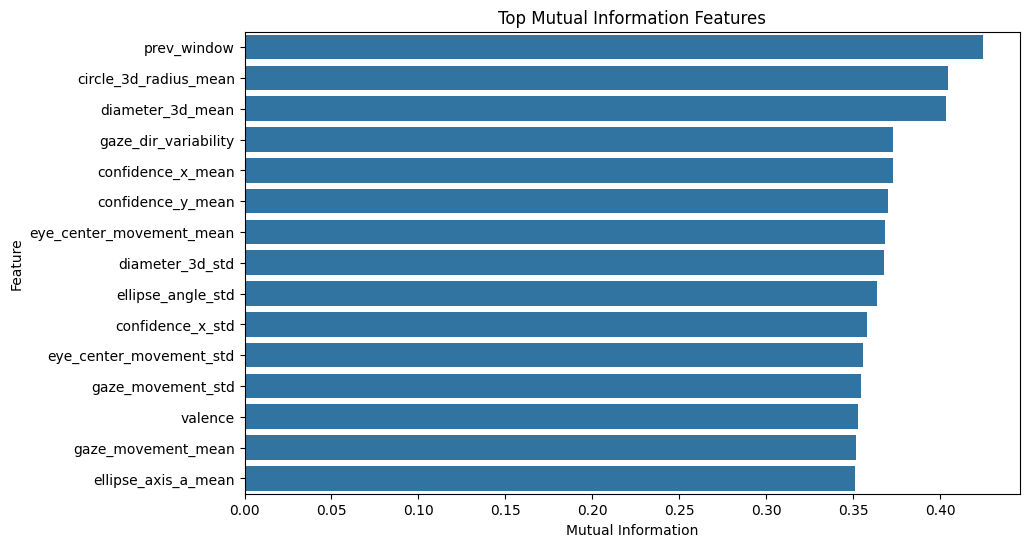

In [9]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, discrete_features='auto')
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.head(15), y=mi_series.head(15).index)
plt.title("Top Mutual Information Features")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.show()


In [10]:
from sklearn.feature_selection import VarianceThreshold

# Low variance filter
selector = VarianceThreshold(threshold=0.01)
selector.fit(X)
low_variance_features = X.columns[~selector.get_support()]

# High missing values
missing_ratios = df.isnull().mean()
high_missing = missing_ratios[missing_ratios > 0.3]

print("Low variance features:", low_variance_features.tolist())
print("High missing value features:", high_missing.index.tolist())


Low variance features: ['GSR_variance', 'HR_variance', 'HRmean_persent_diff', 'HRmean_diff', 'sphere_radius_mean', 'confidence_x_mean', 'confidence_y_mean', 'confidence_x_std', 'confidence_y_std', 'gaze_dir_variability', 'missing_value_ratio']
High missing value features: []


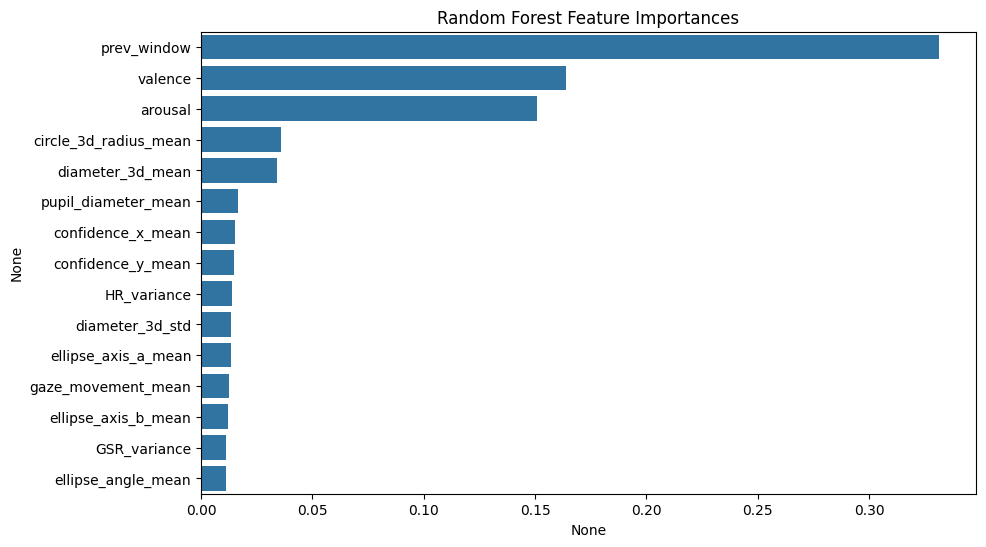

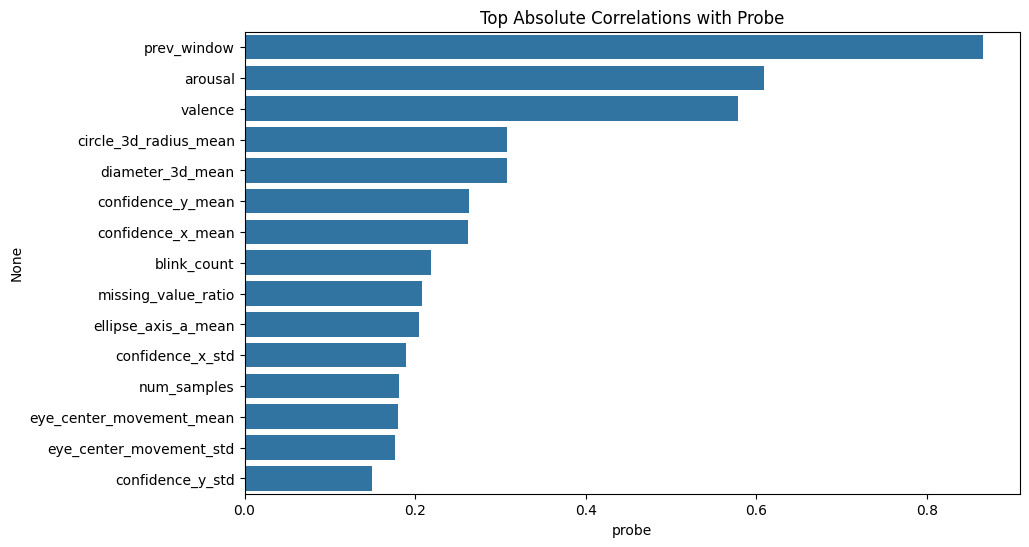

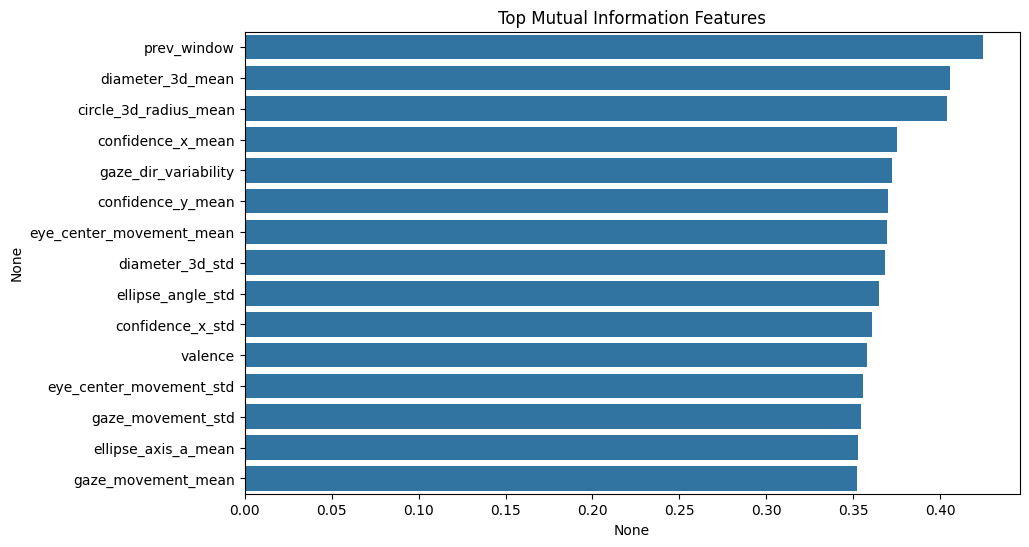

/home/rounak/CODE/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/rounak/CODE/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

✅ Top 20 features selected by RFE: ['HR_mean', '75_percentile_GSR', 'GSRmean_persen_diff', 'HRmean_persent_diff', 'GSRmean_diff', 'HRmean_diff', 'valence_acc_video', 'arousal_acc_video', 'Score', 'valence', 'arousal', 'prev_window', 'diameter_3d_mean', 'diameter_3d_std', 'sphere_radius_mean', 'circle_3d_radius_mean', 'ellipse_axis_a_mean', 'confidence_x_std', 'confidence_y_std', 'gaze_dir_variability']


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X.select_dtypes(include='number'), y, test_size=0.2, random_state=42)

# ---- Random Forest Feature Importance ----
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.head(15), y=rf_importances.head(15).index)
plt.title("Random Forest Feature Importances")
plt.show()

# ---- Correlation with Probe ----
corr = df[X.columns.tolist() + ['probe']].corr(numeric_only=True)
probe_corr = corr['probe'].drop('probe').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=probe_corr.head(15).abs(), y=probe_corr.head(15).index)
plt.title("Top Absolute Correlations with Probe")
plt.show()

# ---- Mutual Information ----
mi = mutual_info_classif(X, y)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.head(15), y=mi_series.head(15).index)
plt.title("Top Mutual Information Features")
plt.show()

# ---- RFE (Recursive Feature Elimination) ----
rfe_model = LogisticRegression(max_iter=1000)
rfe = RFE(rfe_model, n_features_to_select=20)
rfe.fit(X, y)

selected_rfe = X.columns[rfe.support_]
print("✅ Top 20 features selected by RFE:", selected_rfe.tolist())


In [12]:
df.columns

Index(['GSR_mean', 'GSR_variance', 'HR_mean', 'HR_variance',
       '75_percentile_GSR', '75_percentile_HR', 'GSRmean_persen_diff',
       'HRmean_persent_diff', 'GSRmean_diff', 'HRmean_diff',
       'valence_acc_video', 'arousal_acc_video', 'Score', 'valence', 'arousal',
       'probe', 'prev_window', 'num_samples', 'pupil_diameter_mean',
       'pupil_diameter_std', 'diameter_3d_mean', 'diameter_3d_std',
       'sphere_radius_mean', 'circle_3d_radius_mean', 'ellipse_axis_a_mean',
       'ellipse_axis_b_mean', 'ellipse_angle_mean', 'ellipse_angle_std',
       'confidence_x_mean', 'confidence_y_mean', 'confidence_x_std',
       'confidence_y_std', 'blink_count', 'gaze_movement_mean',
       'gaze_movement_std', 'gaze_dir_variability', 'eye_center_movement_mean',
       'eye_center_movement_std', 'missing_value_ratio'],
      dtype='object')

# Feature Analysis Report

In [13]:
# Feature Analysis Report


🔍 Correlation of each feature with the target variable 'probe':
circle_3d_radius_mean      -0.307229
diameter_3d_mean           -0.307229
confidence_y_mean          -0.263529
confidence_x_mean          -0.261485
blink_count                 0.218759
missing_value_ratio         0.208156
ellipse_axis_a_mean        -0.204116
confidence_x_std            0.189117
num_samples                -0.180975
eye_center_movement_mean    0.179607
eye_center_movement_std     0.176899
confidence_y_std            0.148897
diameter_3d_std             0.135045
gaze_movement_mean          0.116359
gaze_dir_variability        0.114458
arousal_acc_video          -0.103597
gaze_movement_std           0.099845
ellipse_angle_mean          0.082097
ellipse_axis_b_mean         0.077837
pupil_diameter_mean         0.077837
pupil_diameter_std          0.077733
valence_acc_video           0.066822
HR_mean                     0.058295
ellipse_angle_std          -0.056051
75_percentile_GSR          -0.055470
HR_varianc

/tmp/ipykernel_670960/2374593714.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_probe_corr.values, y=top_probe_corr.index, palette='coolwarm')


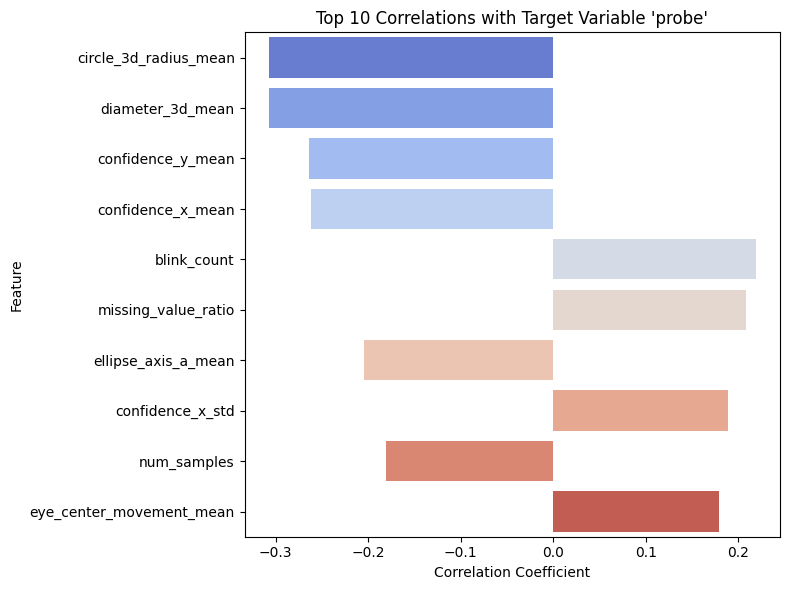

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Drop irrelevant columns
drop_cols = [
    'start_time', 'start_time_sec', 'start_time_ms',
    'end_time', 'end_time_sec', 'end_time_ms', 'time',
    'P_id', 'video_id', 'videoID', 'arousal', 'valence', 'prev_window'
]
df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Step 2: Compute Pearson correlation matrix
corr_matrix = df_clean.corr(method='pearson')

# Step 3: Focus on correlations with 'probe'
if 'probe' in corr_matrix.columns:
    print("\n🔍 Correlation of each feature with the target variable 'probe':")
    probe_corr = corr_matrix['probe'].drop('probe').sort_values(key=abs, ascending=False)
    print(probe_corr.to_string())

    # Optional: visualize top 10 correlated features with probe
    top_n = 10
    top_probe_corr = probe_corr.head(top_n)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_probe_corr.values, y=top_probe_corr.index, palette='coolwarm')
    plt.title(f"Top {top_n} Correlations with Target Variable 'probe'")
    plt.xlabel("Correlation Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("The column 'probe' was not found in the DataFrame.")



🔍 Top 10 correlations with 'probe':
75_percentile_HR         0.331901
GSR_mean                -0.322416
75_percentile_GSR       -0.318452
HR_mean                  0.315759
HR_variance              0.256063
GSRmean_diff             0.251884
GSRmean_persen_diff      0.251884
HRmean_diff             -0.221286
HRmean_persent_diff     -0.221286
circle_3d_radius_mean    0.132695
Name: Score, dtype: float64


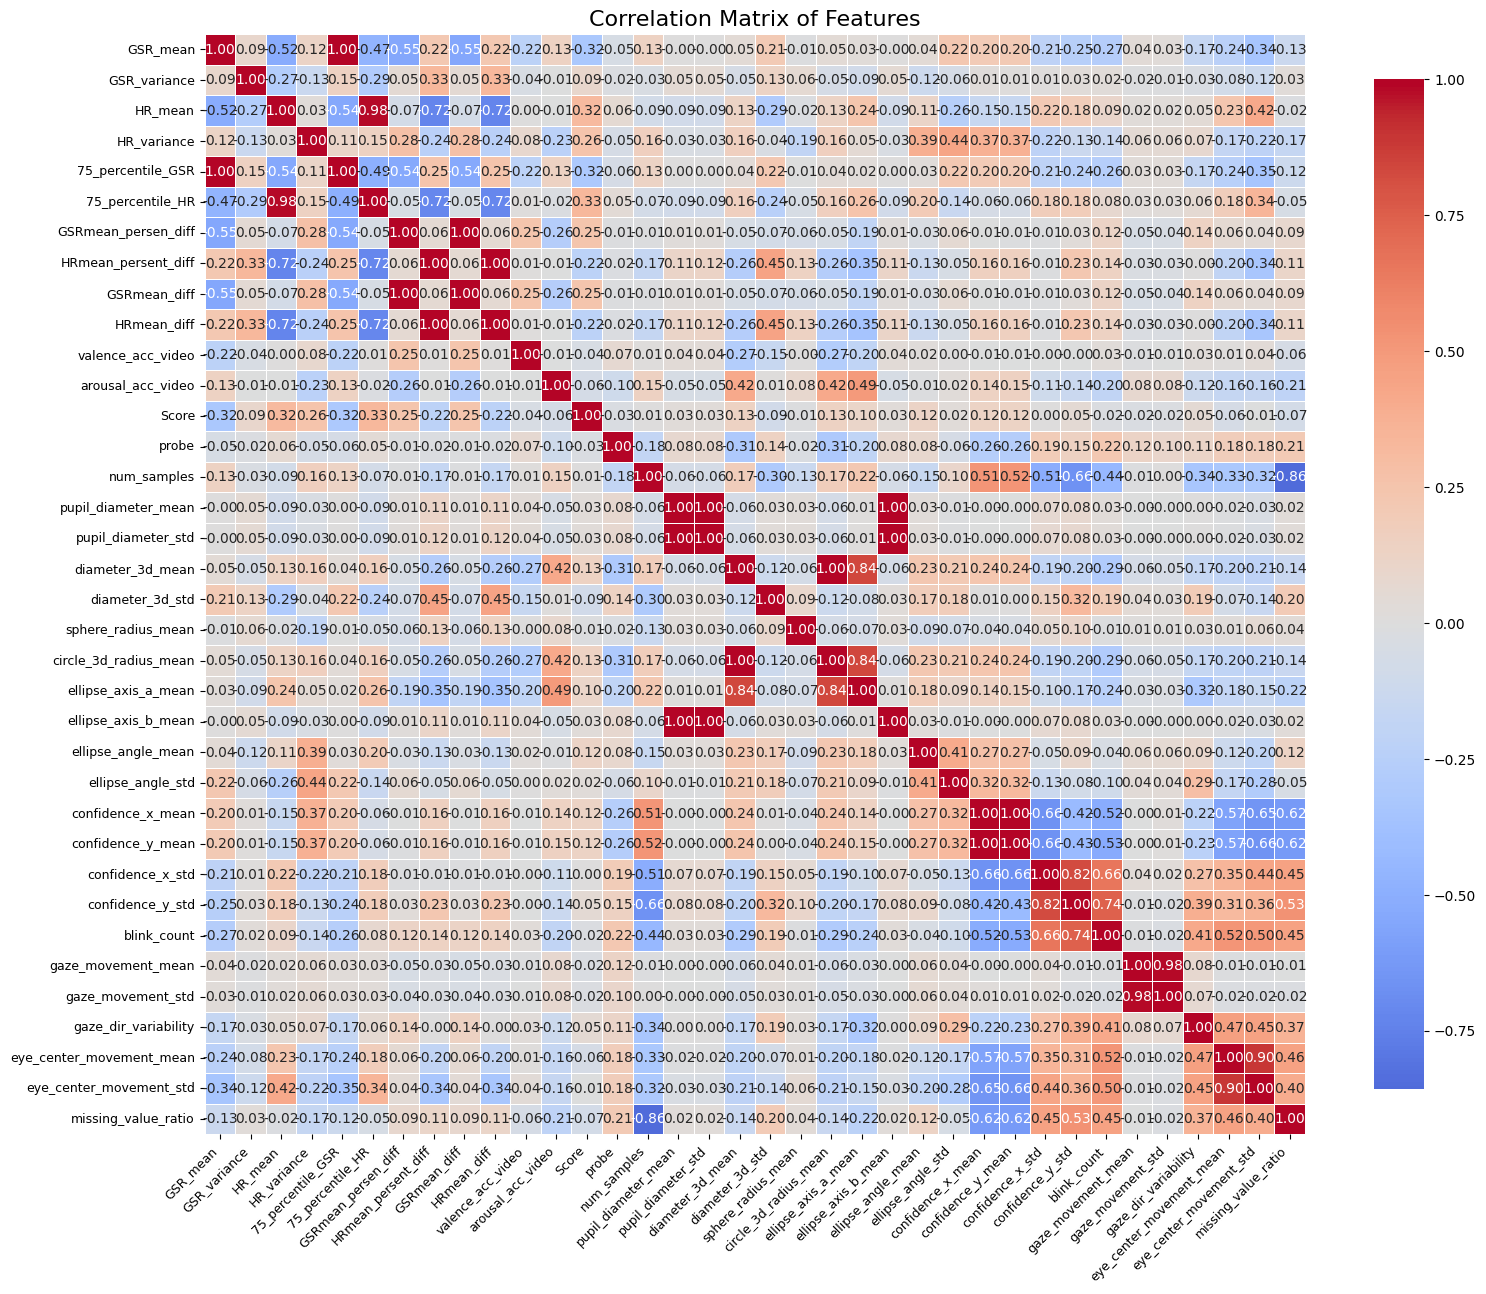

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Drop unwanted columns
drop_cols = [
    'start_time', 'start_time_sec', 'start_time_ms',
    'end_time', 'end_time_sec', 'end_time_ms', 'time',
    'P_id', 'video_id', 'videoID', 'arousal', 'valence', 'prev_window'
]

# Drop columns that are present
df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Step 2: Compute Pearson correlation matrix
corr_matrix = df_clean.corr(method='pearson')

# Step 3: Print top correlations with 'Score' (if it exists)
if 'probe' in corr_matrix.columns:
    print("\n🔍 Top 10 correlations with 'probe':")
    score_corr = corr_matrix['Score'].drop('Score').sort_values(key=abs, ascending=False)
    print(score_corr.head(10))

# # Step 4: Print highly correlated feature pairs (absolute value > 0.85)
# print("\n📌 Highly correlated feature pairs (|correlation| > 0.85):")
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
# high_corr = corr_matrix.where(mask).stack().reset_index()
# high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']
# strong_corr_pairs = high_corr[abs(high_corr['Correlation']) > 0.85]
# print(strong_corr_pairs)

# Step 5: Plot heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation Matrix of Features", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


In [15]:
# Correlation of each feature with the label 'probe'
target_corr = corr_matrix['probe'].drop('probe').sort_values(key=abs, ascending=False)

# Display top N most correlated features with the label
top_n = 20
print("Top features correlated with 'probe':")
print(target_corr.head(top_n))


Top features correlated with 'probe':
circle_3d_radius_mean      -0.307229
diameter_3d_mean           -0.307229
confidence_y_mean          -0.263529
confidence_x_mean          -0.261485
blink_count                 0.218759
missing_value_ratio         0.208156
ellipse_axis_a_mean        -0.204116
confidence_x_std            0.189117
num_samples                -0.180975
eye_center_movement_mean    0.179607
eye_center_movement_std     0.176899
confidence_y_std            0.148897
diameter_3d_std             0.135045
gaze_movement_mean          0.116359
gaze_dir_variability        0.114458
arousal_acc_video          -0.103597
gaze_movement_std           0.099845
ellipse_angle_mean          0.082097
ellipse_axis_b_mean         0.077837
pupil_diameter_mean         0.077837
Name: probe, dtype: float64


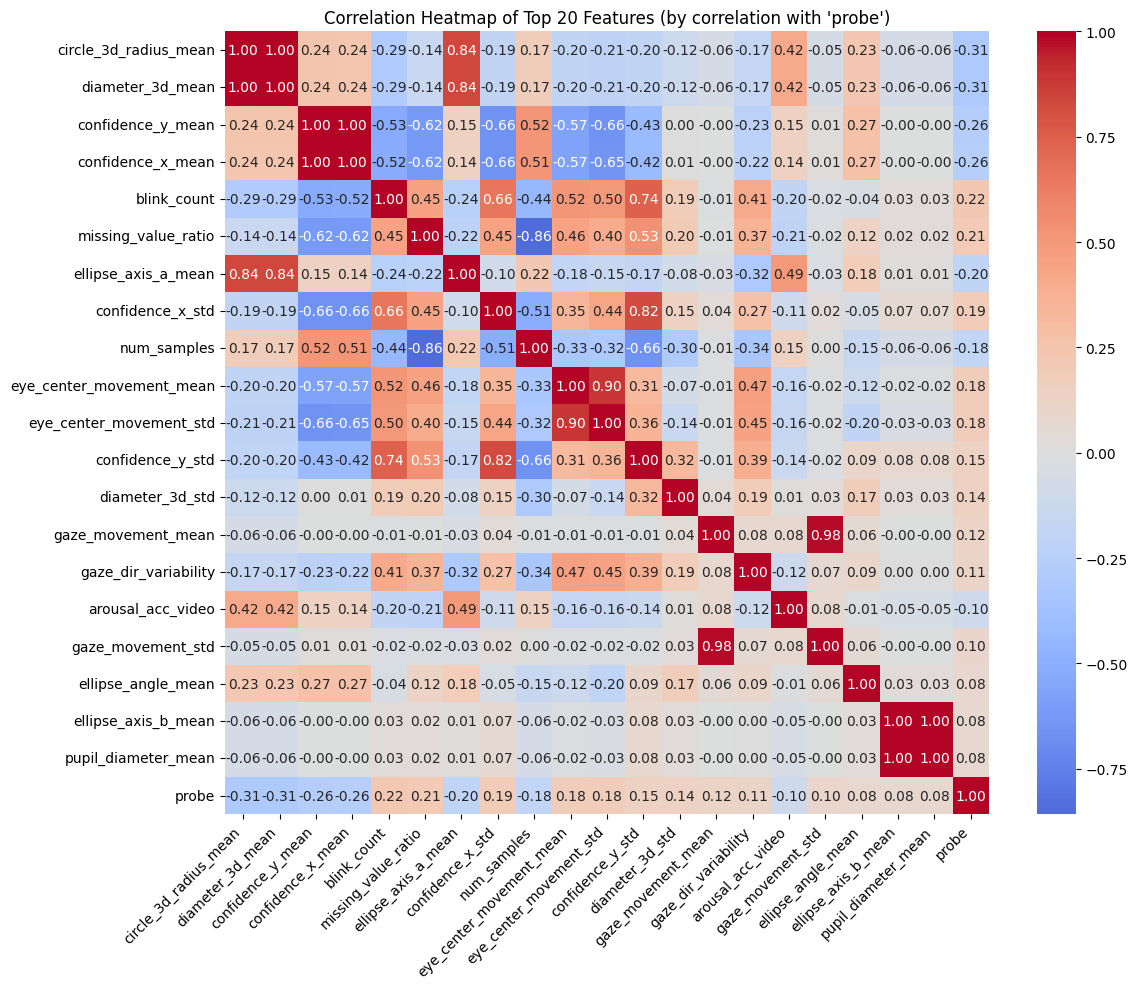

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Keep only top-N correlated features with 'probe'
top_n = 20

# Assuming 'corr_matrix' and 'df_clean' already exist
# If not, recompute as in earlier step
target_corr = df_clean.corr()['probe'].drop('probe')
top_features = target_corr.abs().sort_values(ascending=False).head(top_n).index.tolist()

# Include 'probe' for correlation context
top_features_with_label = top_features + ['probe']

# Step 2: Subset the correlation matrix
filtered_corr = df_clean[top_features_with_label].corr()

# Step 3: Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title(f"Correlation Heatmap of Top {top_n} Features (by correlation with 'probe')")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


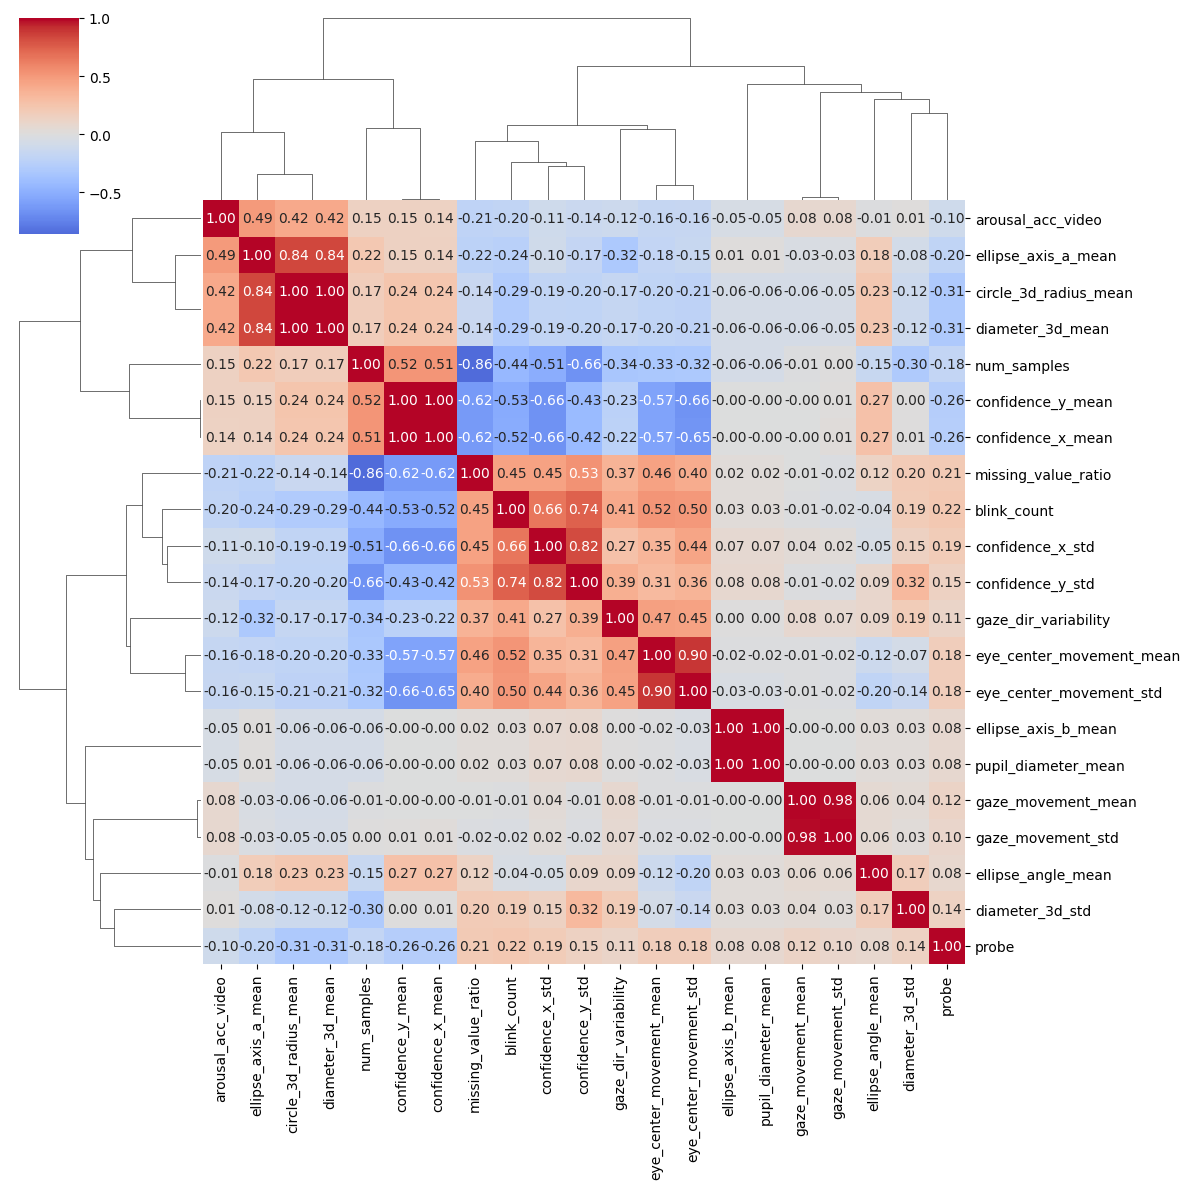

In [17]:
sns.clustermap(filtered_corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', figsize=(12, 12))


/tmp/ipykernel_670960/962048373.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(top_n), x='Importance', y='Feature', palette='viridis')


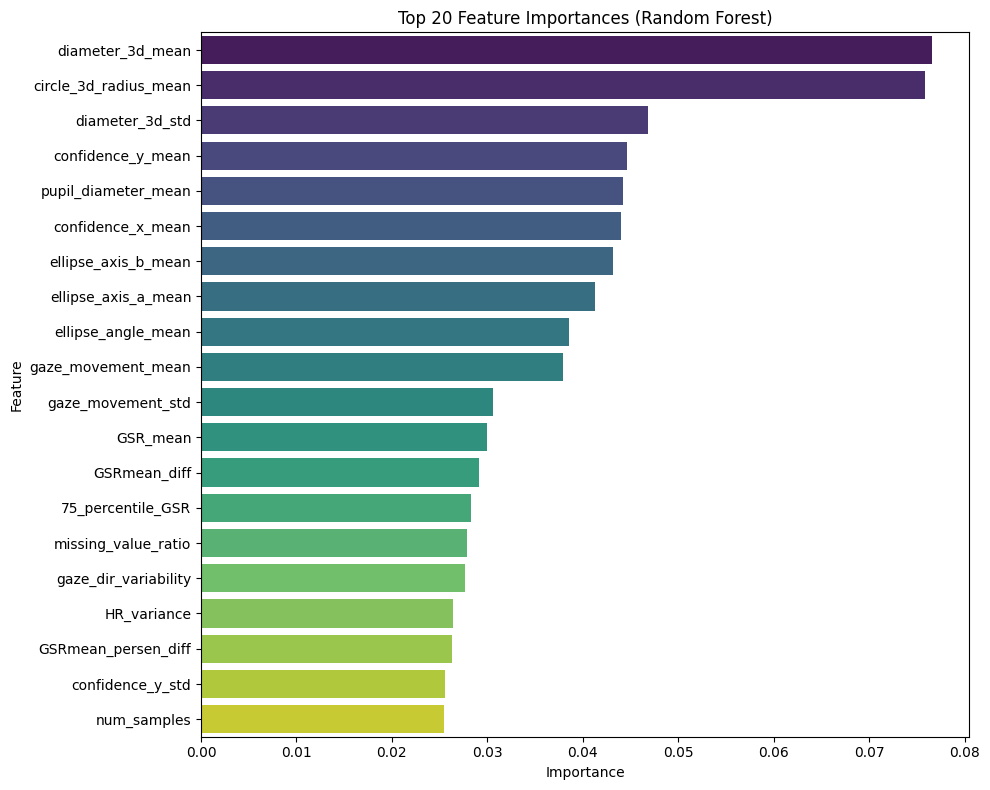

                  Feature  Importance
16       diameter_3d_mean    0.076629
19  circle_3d_radius_mean    0.075879
17        diameter_3d_std    0.046790
25      confidence_y_mean    0.044638
14    pupil_diameter_mean    0.044162
24      confidence_x_mean    0.043965
21    ellipse_axis_b_mean    0.043111
20    ellipse_axis_a_mean    0.041301
22     ellipse_angle_mean    0.038583
29     gaze_movement_mean    0.037881
30      gaze_movement_std    0.030635
0                GSR_mean    0.029911
8            GSRmean_diff    0.029113
4       75_percentile_GSR    0.028298
34    missing_value_ratio    0.027913
31   gaze_dir_variability    0.027638
3             HR_variance    0.026446
6     GSRmean_persen_diff    0.026297
27       confidence_y_std    0.025553
13            num_samples    0.025424
X_train shape: (1497, 35)
X_test shape: (499, 35)
y_train distribution:
probe
0.0    0.669339
1.0    0.330661
Name: proportion, dtype: float64
Random Forest accuracy: 0.95


In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Prepare data
X = df_clean.drop(columns='probe')
y = df_clean['probe']

# Optional: handle missing values
X = X.fillna(X.median())

# Step 2: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Step 3: Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 4: Get feature importances
importances = rf.feature_importances_
features = X.columns

# Put into DataFrame and sort
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)



# Step 5: Plot top N features
top_n = 20
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df.head(top_n), x='Importance', y='Feature', palette='viridis')
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


print(feat_imp_df.head(top_n))
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")

from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest accuracy: {accuracy:.2f}")




[LightGBM] [Info] Number of positive: 495, number of negative: 1002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000582 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7586
[LightGBM] [Info] Number of data points in the train set: 1497, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.330661 -> initscore=-0.705196
[LightGBM] [Info] Start training from score -0.705196


/tmp/ipykernel_670960/130138735.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')


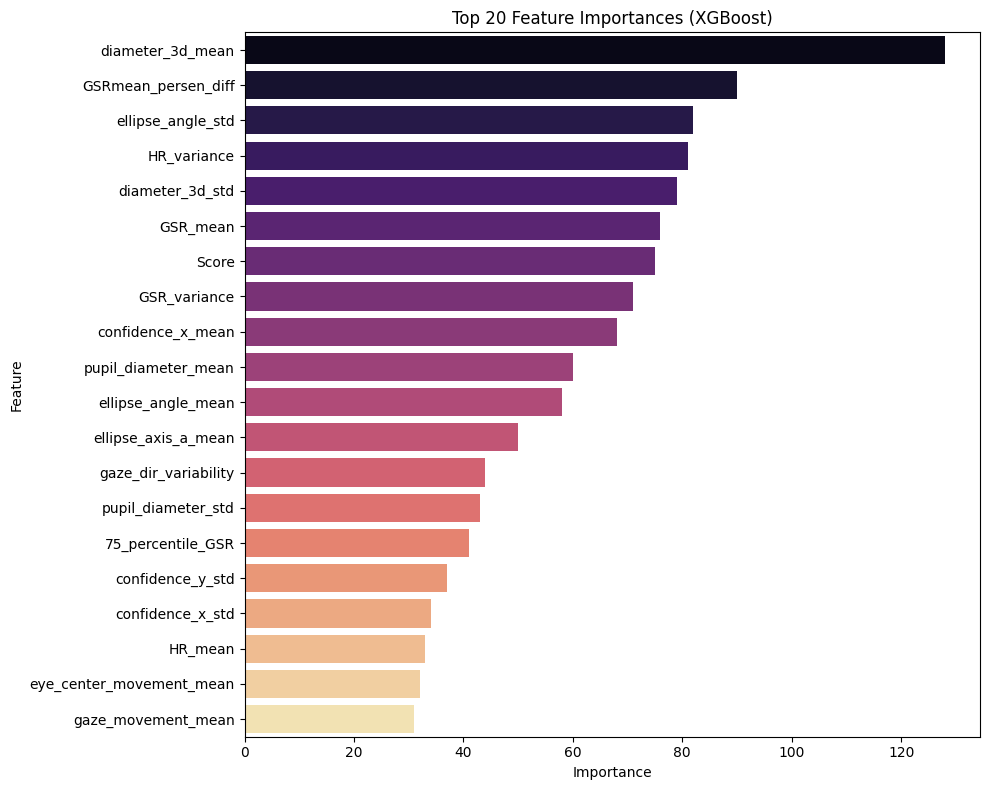

/tmp/ipykernel_670960/130138735.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')


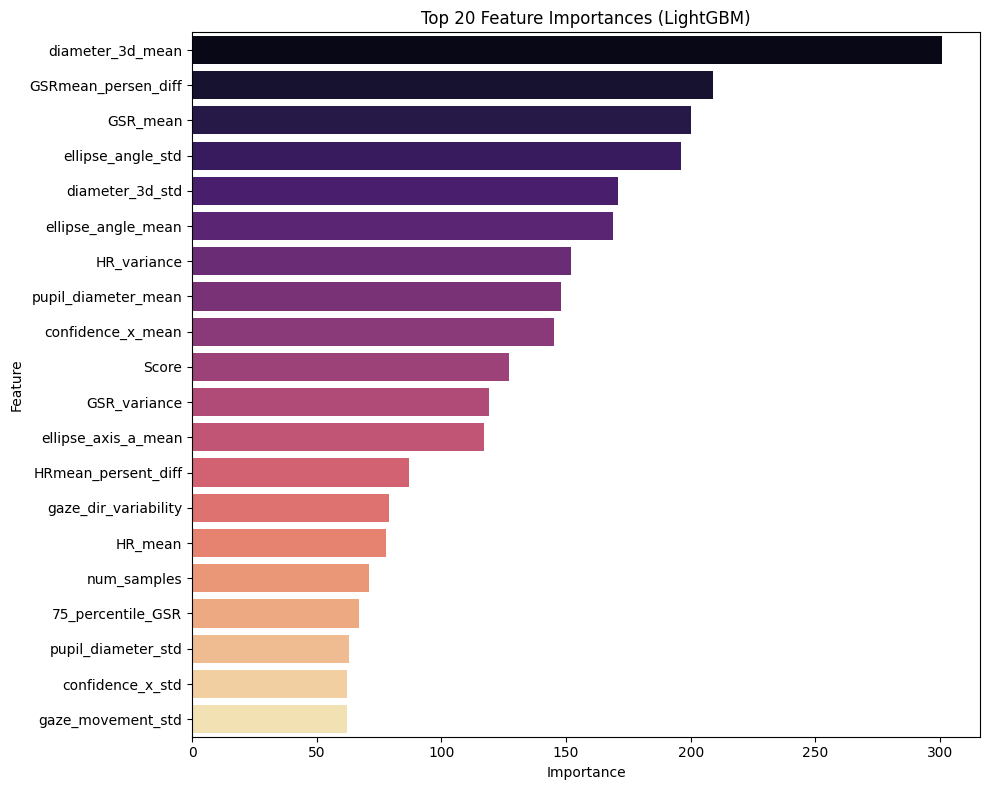


Top 10 features from XGBoost:
                Feature  Importance
16     diameter_3d_mean       128.0
6   GSRmean_persen_diff        90.0
23    ellipse_angle_std        82.0
3           HR_variance        81.0
17      diameter_3d_std        79.0
0              GSR_mean        76.0
12                Score        75.0
1          GSR_variance        71.0
24    confidence_x_mean        68.0
14  pupil_diameter_mean        60.0

Top 10 features from LightGBM:
                Feature  Importance
16     diameter_3d_mean         301
6   GSRmean_persen_diff         209
0              GSR_mean         200
23    ellipse_angle_std         196
17      diameter_3d_std         171
22   ellipse_angle_mean         169
3           HR_variance         152
14  pupil_diameter_mean         148
24    confidence_x_mean         145
12                Score         127

XGBoost Accuracy: 0.96
LightGBM Accuracy: 0.96


In [53]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Store results for comparison
importance_results = {}

# 1. XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

# xgb_importances = xgb.feature_importances_
# xgb_df = pd.DataFrame({'Feature': X.columns, 'Importance': xgb_importances})
# xgb_df = xgb_df.sort_values(by='Importance', ascending=False)
# importance_results['XGBoost'] = xgb_df

# Get importance from XGBoost booster
xgb_booster = xgb.get_booster()
raw_importances = xgb_booster.get_score(importance_type='weight')

# Create complete importance dict (fill missing with 0)
all_features = X.columns.tolist()
full_importance = {feat: raw_importances.get(feat, 0.0) for feat in all_features}

# Convert to DataFrame
xgb_df = pd.DataFrame({'Feature': list(full_importance.keys()), 
                       'Importance': list(full_importance.values())})
xgb_df = xgb_df.sort_values(by='Importance', ascending=False)




# 2. LightGBM
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
lgbm.fit(X_train, y_train)

lgbm_importances = lgbm.feature_importances_
lgbm_df = pd.DataFrame({'Feature': X.columns, 'Importance': lgbm_importances})
lgbm_df = lgbm_df.sort_values(by='Importance', ascending=False)
importance_results['LightGBM'] = lgbm_df

# 3. Optional: combine and compare top features side-by-side
def plot_feature_importance(df, model_name, top_n=20):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')
    plt.title(f'Top {top_n} Feature Importances ({model_name})')
    plt.tight_layout()
    plt.show()

# Plot XGBoost
plot_feature_importance(xgb_df, 'XGBoost')

# Plot LightGBM
plot_feature_importance(lgbm_df, 'LightGBM')

# Print top 10 features from both models
print("\nTop 10 features from XGBoost:")
print(xgb_df.head(10))

print("\nTop 10 features from LightGBM:")
print(lgbm_df.head(10))

# Optional: Evaluate and print accuracy for both models
from sklearn.metrics import accuracy_score

xgb_preds = xgb.predict(X_test)
lgbm_preds = lgbm.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_preds)
lgbm_acc = accuracy_score(y_test, lgbm_preds)

print(f"\nXGBoost Accuracy: {xgb_acc:.2f}")
print(f"LightGBM Accuracy: {lgbm_acc:.2f}")



In [20]:
X.describe(include='all').T


,count,mean,std,min,25%,50%,75%,max
GSR_mean,1996.0,5.821681e-01,2.372530e-01,0.048793,0.388103,0.546379,0.816316,9.409483e-01
GSR_variance,1996.0,1.281193e-03,2.410487e-03,0.000015,0.000413,0.000634,0.002115,5.033424e-02
HR_mean,1996.0,4.017386e-01,1.065046e-01,0.244468,0.312000,0.424296,0.461396,5.742857e-01
HR_variance,1996.0,6.237933e-03,8.048723e-03,0.000005,0.000700,0.003379,0.008265,5.209067e-02
75_percentile_GSR,1996.0,6.046805e-01,2.419116e-01,0.064655,0.400862,0.563636,0.842105,9.784483e-01
75_percentile_HR,1996.0,4.265818e-01,1.187738e-01,0.244681,0.333333,0.454717,0.472642,7.023810e-01
GSRmean_persen_diff,1996.0,1.456894e-01,1.512146e-01,0.000143,0.053473,0.100509,0.181436,7.741858e-01
HRmean_persent_diff,1996.0,7.250751e-02,9.757601e-02,0.000010,0.001236,0.023211,0.091782,2.501972e-01
GSRmean_diff,1996.0,1.456894e-01,1.512146e-01,0.000143,0.053473,0.100509,0.181436,7.741858e-01
HRmean_diff,1996.0,7.250751e-02,9.757601e-02,0.000010,0.001236,0.023211,0.091782,2.501972e-01


/home/rounak/CODE/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:41:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 495, number of negative: 1002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6343
[LightGBM] [Info] Number of data points in the train set: 1497, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.330661 -> initscore=-0.705196
[LightGBM] [Info] Start training from score -0.705196


/tmp/ipykernel_670960/3278568842.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')


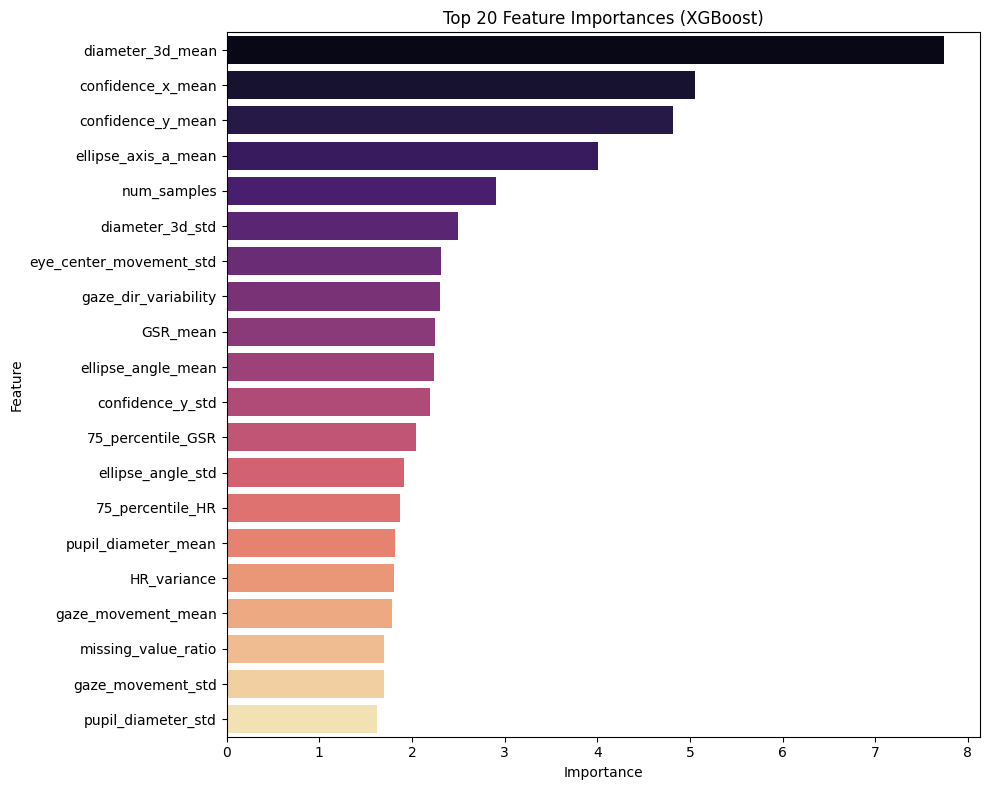

/tmp/ipykernel_670960/3278568842.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')


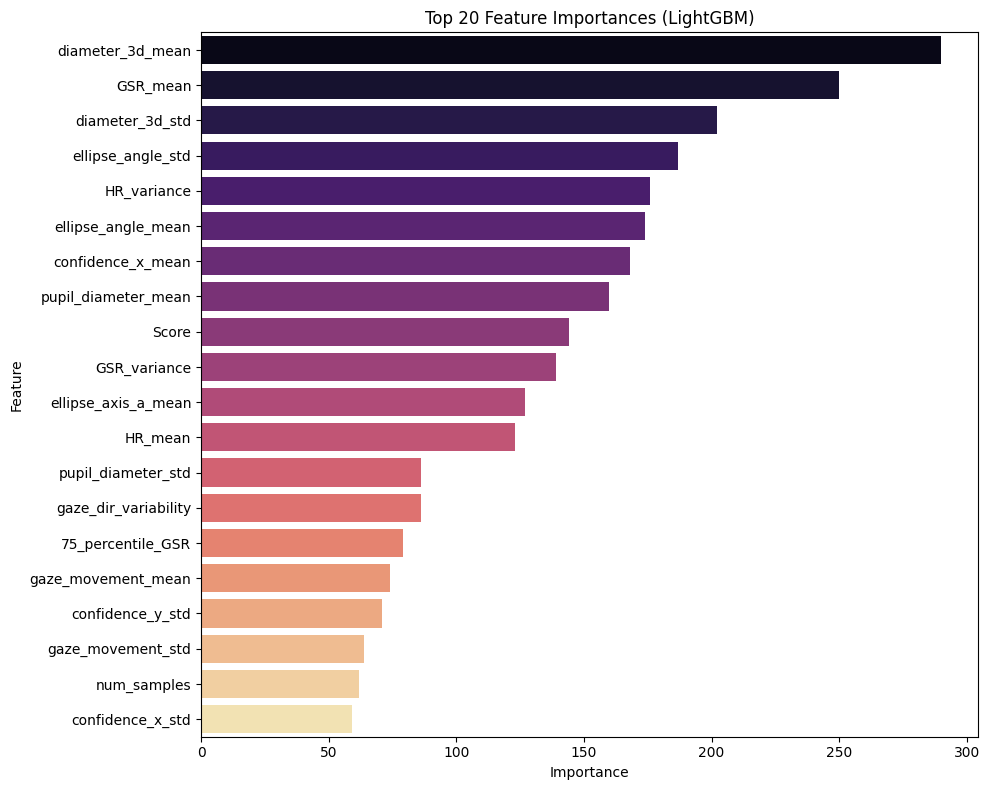

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- CLEANING STEPS ---

# 1. Drop constant feature
X = X.drop(columns=['sphere_radius_mean'], errors='ignore')

# 2. Drop duplicate/redundant features
redundant_cols = [
    'GSRmean_diff', 'GSRmean_persen_diff',
    'HRmean_diff', 'HRmean_persent_diff',
    'ellipse_axis_b_mean'  # same as pupil_diameter_mean
]
X = X.drop(columns=[col for col in redundant_cols if col in X.columns])

# 3. Handle outliers (clip to 99th percentile)
clip_cols = ['pupil_diameter_mean', 'pupil_diameter_std']
for col in clip_cols:
    if col in X.columns:
        upper_bound = X[col].quantile(0.99)
        X[col] = X[col].clip(upper=upper_bound)

# 4. Align train/test (assuming you already split into X_train, X_test)
X_train = X.loc[y_train.index]
X_test = X.loc[y_test.index]

# --- FEATURE IMPORTANCE ANALYSIS ---

# Store results for comparison
importance_results = {}

# --- XGBoost ---
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb.fit(X_train, y_train)

# Get feature importance from booster
xgb_booster = xgb.get_booster()
raw_importances = xgb_booster.get_score(importance_type='gain')

# Fill in missing features with 0 importance
xgb_full_importance = {feat: raw_importances.get(feat, 0.0) for feat in X.columns}
xgb_df = pd.DataFrame({'Feature': list(xgb_full_importance.keys()), 
                       'Importance': list(xgb_full_importance.values())})
xgb_df = xgb_df.sort_values(by='Importance', ascending=False)
importance_results['XGBoost'] = xgb_df

# --- LightGBM ---
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
lgbm.fit(X_train, y_train)

lgbm_importances = lgbm.feature_importances_
lgbm_df = pd.DataFrame({'Feature': X.columns, 'Importance': lgbm_importances})
lgbm_df = lgbm_df.sort_values(by='Importance', ascending=False)
importance_results['LightGBM'] = lgbm_df

# --- PLOT FUNCTION ---
def plot_feature_importance(df, model_name, top_n=20):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')
    plt.title(f'Top {top_n} Feature Importances ({model_name})')
    plt.tight_layout()
    plt.show()

# --- PLOTS ---
plot_feature_importance(xgb_df, 'XGBoost')
plot_feature_importance(lgbm_df, 'LightGBM')


/home/rounak/CODE/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


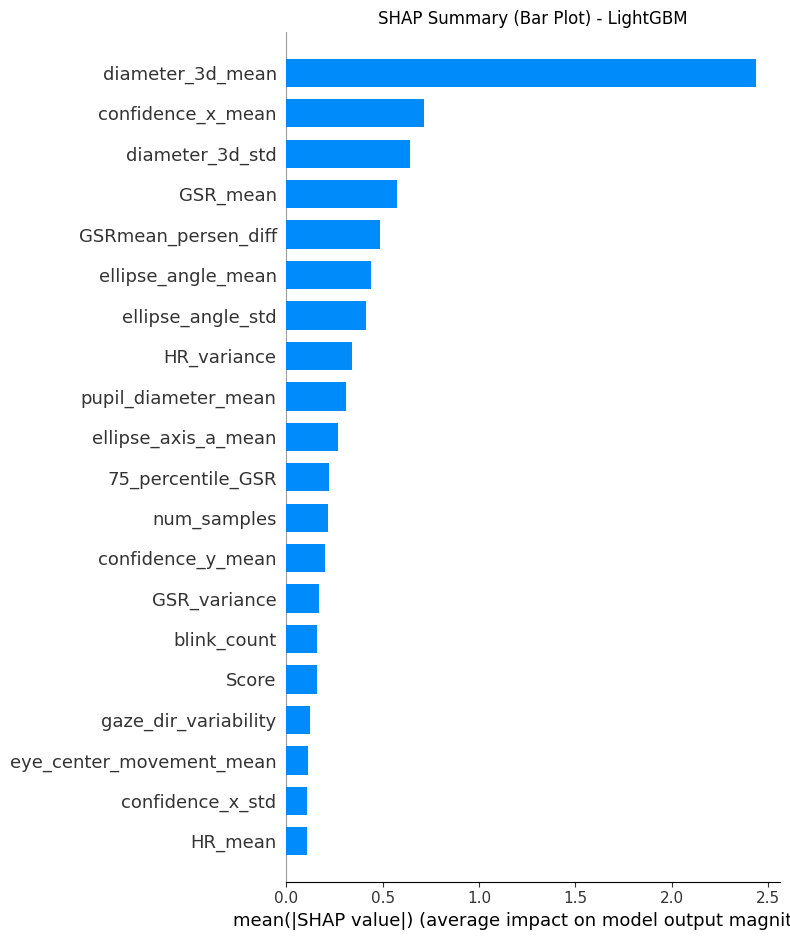

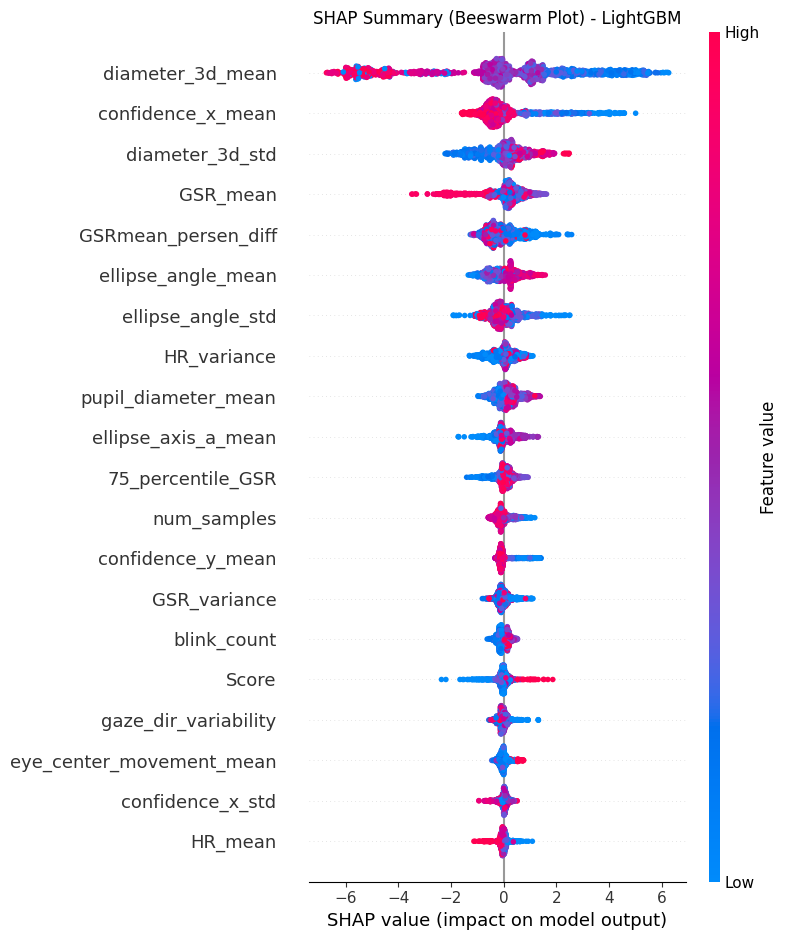

SHAP analysis complete.
SHAP values shape: (1497, 35)
Number of features: 35
Top 5 features by mean absolute SHAP value:
                Feature  Mean |SHAP value|
16     diameter_3d_mean           2.438161
24    confidence_x_mean           0.712605
17      diameter_3d_std           0.643504
0              GSR_mean           0.576138
6   GSRmean_persen_diff           0.484253


In [54]:
import shap

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)


# Use TreeExplainer directly for LightGBM (no PyTorch/torch dependency)
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_train)

# Summary Plot (Bar)
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("SHAP Summary (Bar Plot) - LightGBM")
plt.tight_layout()
plt.show()

# Summary Plot (Beeswarm)
shap.summary_plot(shap_values, X_train, show=False)
plt.title("SHAP Summary (Beeswarm Plot) - LightGBM")
plt.tight_layout()
plt.show()


# --- PRINT SUMMARY INFO ---
print("SHAP analysis complete.")
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Top 5 features by mean absolute SHAP value:")

# Compute and print top features by mean absolute SHAP value
shap_abs_mean = np.abs(shap_values).mean(axis=0)
top_features = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean |SHAP value|': shap_abs_mean
}).sort_values(by='Mean |SHAP value|', ascending=False)

print(top_features.head(5))



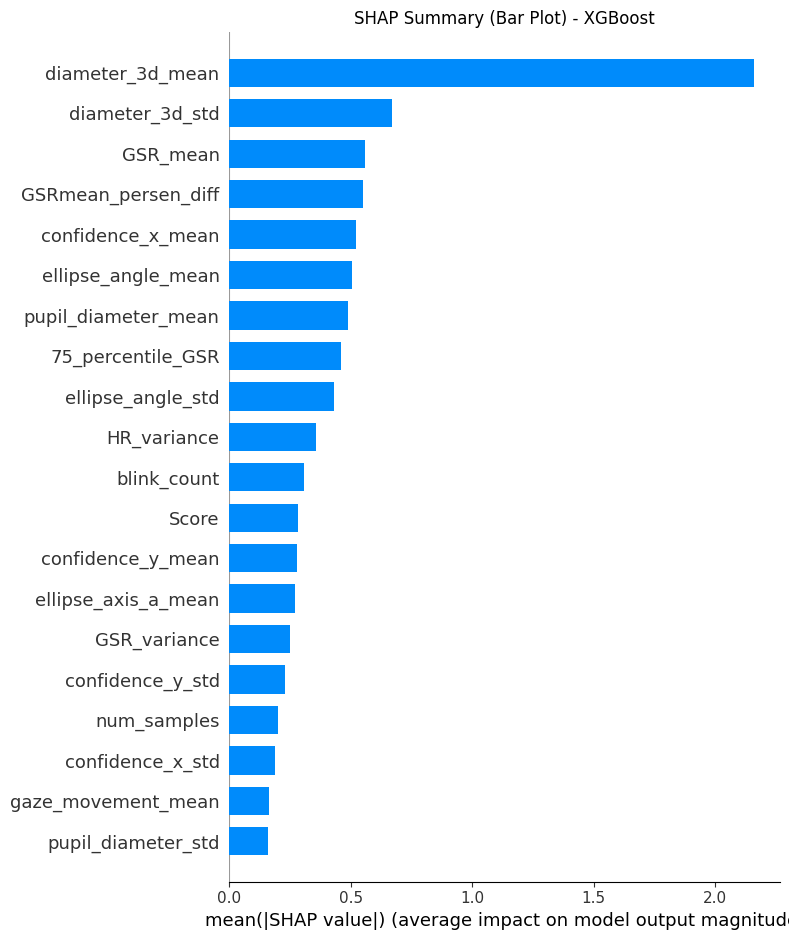

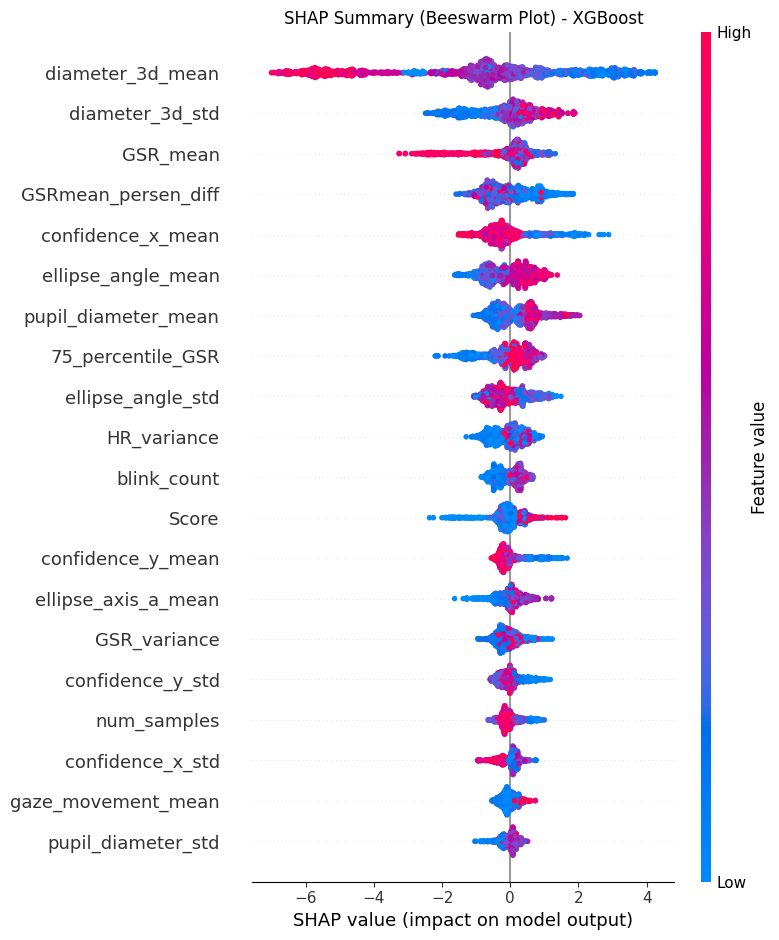

SHAP analysis for XGBoost complete.
SHAP values shape: (1497, 35)
Number of features: 35
Top 5 features by mean absolute SHAP value:
                Feature  Mean |SHAP value|
16     diameter_3d_mean           2.159516
17      diameter_3d_std           0.670055
0              GSR_mean           0.560463
6   GSRmean_persen_diff           0.551546
24    confidence_x_mean           0.523393


In [55]:
import shap
import matplotlib.pyplot as plt

# SHAP for XGBoost
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_train)

# Summary Plot (Bar)
shap.summary_plot(shap_values_xgb, X_train, plot_type="bar", show=False)
plt.title("SHAP Summary (Bar Plot) - XGBoost")
plt.tight_layout()
plt.show()

# Summary Plot (Beeswarm)
shap.summary_plot(shap_values_xgb, X_train, show=False)
plt.title("SHAP Summary (Beeswarm Plot) - XGBoost")
plt.tight_layout()
plt.show()


# --- PRINT SUMMARY INFO ---
print("SHAP analysis for XGBoost complete.")
print(f"SHAP values shape: {np.array(shap_values_xgb).shape}")
print(f"Number of features: {X_train.shape[1]}")
print("Top 5 features by mean absolute SHAP value:")

# Calculate and display top contributing features
shap_abs_mean_xgb = np.abs(shap_values_xgb).mean(axis=0)
top_features_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean |SHAP value|': shap_abs_mean_xgb
}).sort_values(by='Mean |SHAP value|', ascending=False)

print(top_features_xgb.head(5))


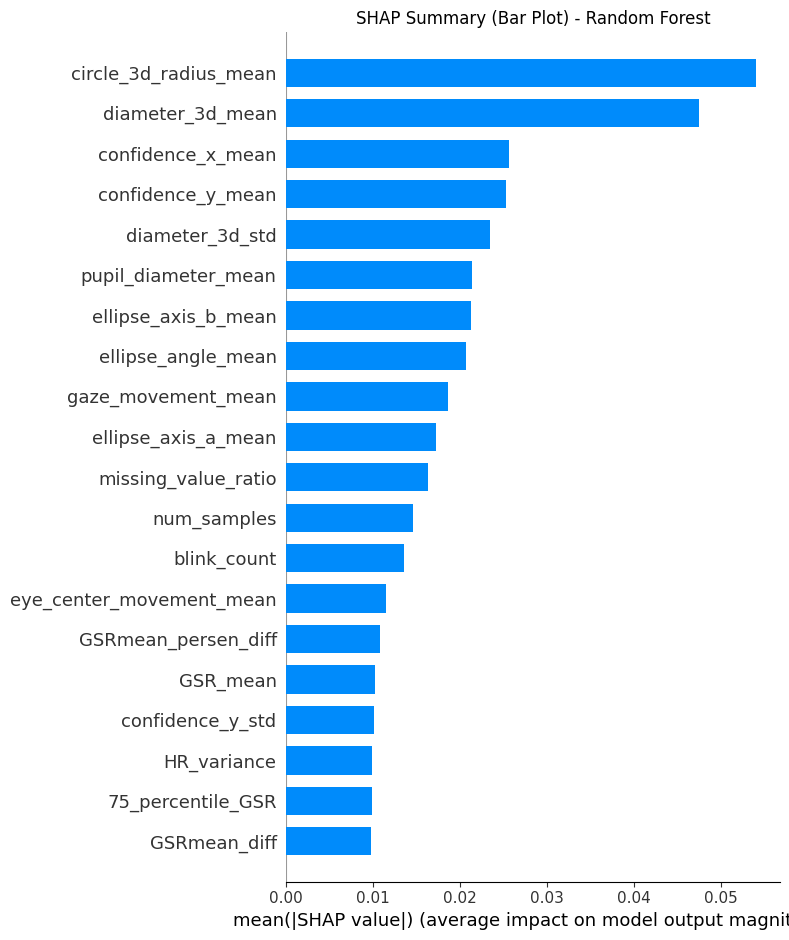

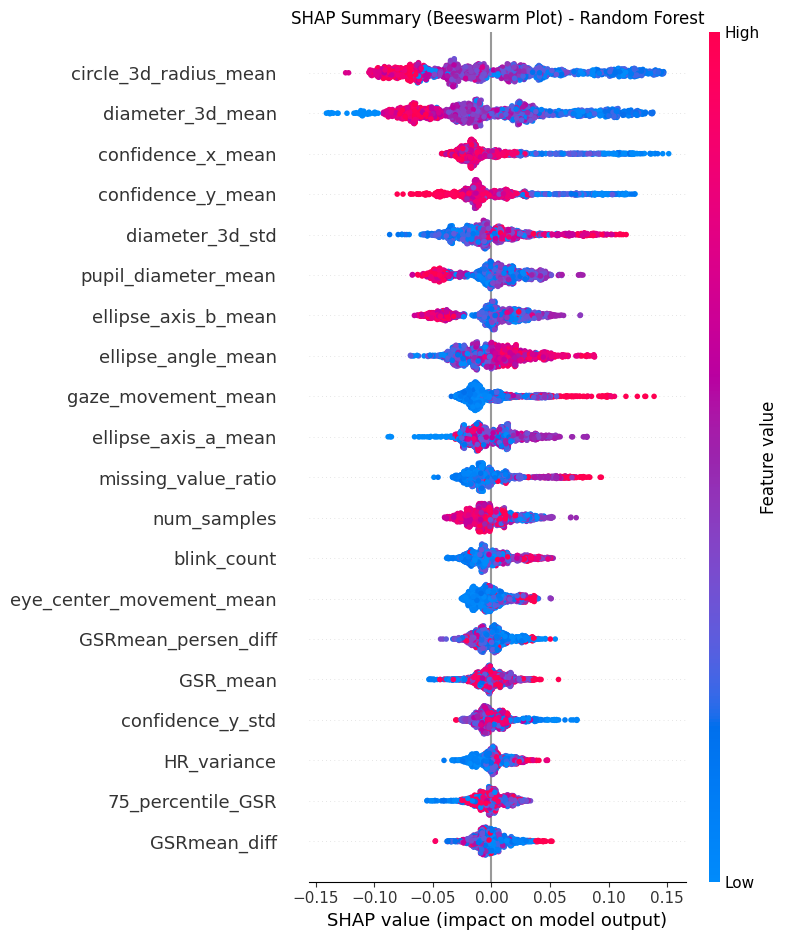

SHAP analysis for Random Forest complete.
SHAP values shape: (1497, 35)
Number of features: 35
Top 5 features by mean absolute SHAP value:
                  Feature  Mean |SHAP value|
19  circle_3d_radius_mean           0.054137
16       diameter_3d_mean           0.047547
24      confidence_x_mean           0.025608
25      confidence_y_mean           0.025329
17        diameter_3d_std           0.023483


In [59]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# SHAP for Random Forest
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_train)  # returns shape (n_samples, n_features, 2)

# Extract SHAP values for positive class (index 1)
shap_values_rf_class1 = shap_values_rf[..., 1]  # Now shape: (n_samples, n_features)

# Summary Plot (Bar)
shap.summary_plot(shap_values_rf_class1, X_train, plot_type="bar", show=False)
plt.title("SHAP Summary (Bar Plot) - Random Forest")
plt.tight_layout()
plt.show()

# Summary Plot (Beeswarm)
shap.summary_plot(shap_values_rf_class1, X_train, show=False)
plt.title("SHAP Summary (Beeswarm Plot) - Random Forest")
plt.tight_layout()
plt.show()

# --- PRINT SUMMARY INFO ---
print("SHAP analysis for Random Forest complete.")
print(f"SHAP values shape: {shap_values_rf_class1.shape}")
print(f"Number of features: {X_train.shape[1]}")
print("Top 5 features by mean absolute SHAP value:")

# Calculate and display top contributing features
shap_abs_mean_rf = np.abs(shap_values_rf_class1).mean(axis=0)
top_features_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean |SHAP value|': shap_abs_mean_rf
}).sort_values(by='Mean |SHAP value|', ascending=False)

print(top_features_rf.head(5))


In [25]:
# Step 4: Mutual Information

/tmp/ipykernel_670960/2089499944.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, y='Feature', x='MI Score', palette='viridis')


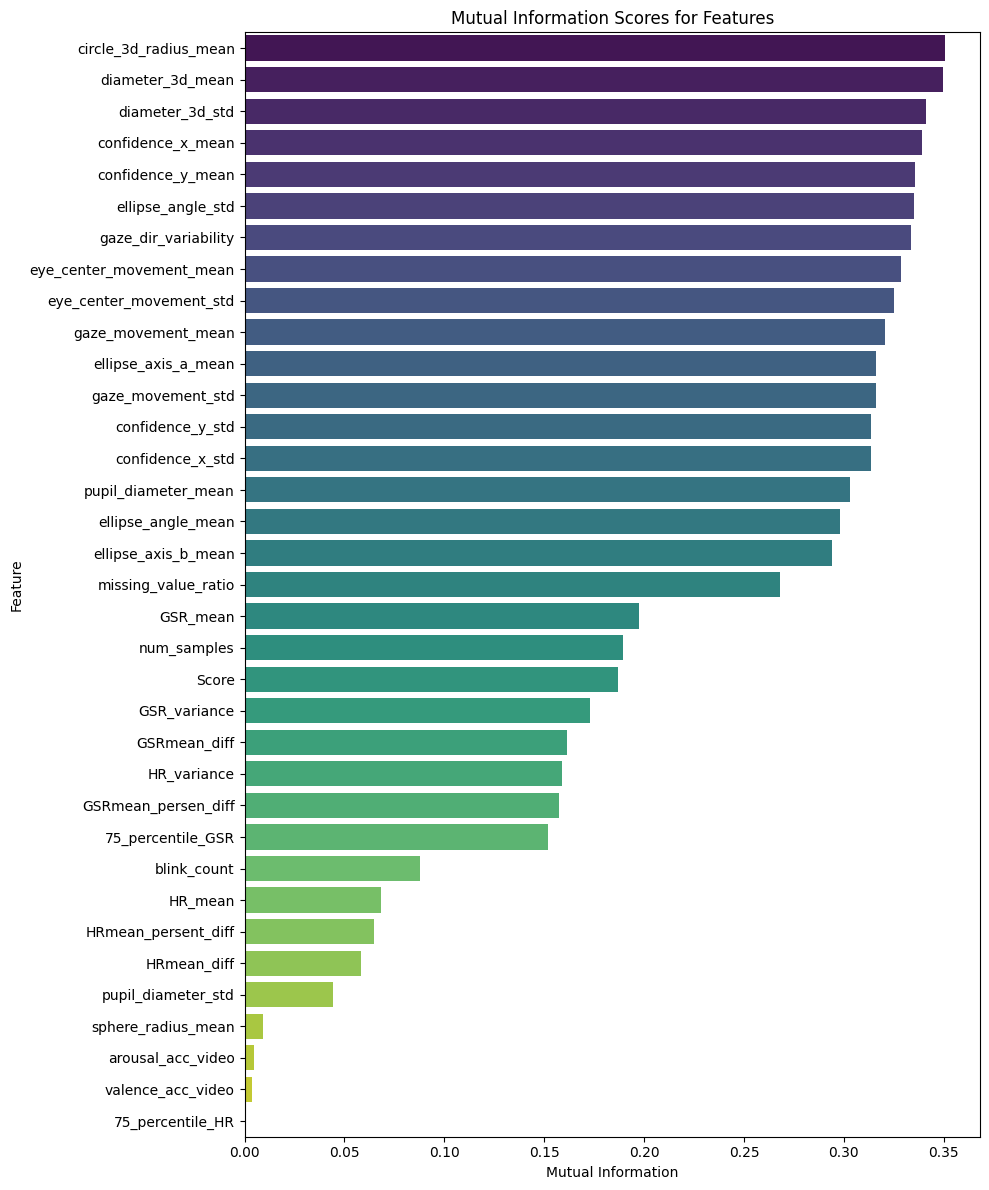

Mutual Information analysis complete.
Number of features evaluated: 35
Top 5 features by Mutual Information score:
                     Feature  MI Score
19     circle_3d_radius_mean  0.350589
16          diameter_3d_mean  0.349709
17           diameter_3d_std  0.341282
24         confidence_x_mean  0.338863
25         confidence_y_mean  0.335794
23         ellipse_angle_std  0.334931
31      gaze_dir_variability  0.333424
32  eye_center_movement_mean  0.328331
33   eye_center_movement_std  0.325235
29        gaze_movement_mean  0.320765


In [60]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute Mutual Information scores
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# Create a DataFrame for better visualization
mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

# Plot the MI scores
plt.figure(figsize=(10, 12))
sns.barplot(data=mi_df, y='Feature', x='MI Score', palette='viridis')
plt.title('Mutual Information Scores for Features')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# --- PRINT SUMMARY INFO ---
print("Mutual Information analysis complete.")
print(f"Number of features evaluated: {len(mi_scores)}")
print("Top 5 features by Mutual Information score:")

print(mi_df.head(10))



In [27]:
mi_df.head(10)

,Feature,MI Score
12,diameter_3d_mean,0.350850
14,circle_3d_radius_mean,0.350097
13,diameter_3d_std,0.343801
18,confidence_x_mean,0.337983
25,gaze_dir_variability,0.336827
17,ellipse_angle_std,0.336195
19,confidence_y_mean,0.334370
26,eye_center_movement_mean,0.327503
27,eye_center_movement_std,0.324951
23,gaze_movement_mean,0.319865


In [28]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd
import numpy as np

# Step 1: Fit SelectKBest with ANOVA F-value
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# Step 2: Create a DataFrame with scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values(by='F_score', ascending=False)

# Step 3: Display top features
print(feature_scores.head(10))


                  Feature     F_score       p_value
12       diameter_3d_mean  207.830450  6.806973e-45
14  circle_3d_radius_mean  207.830450  6.806973e-45
19      confidence_y_mean  148.813405  4.601539e-33
18      confidence_x_mean  146.344719  1.463406e-32
22            blink_count  100.220217  4.726373e-23
10    pupil_diameter_mean   90.848232  4.330192e-21
28    missing_value_ratio   90.310649  5.615328e-21
15    ellipse_axis_a_mean   86.688421  3.242104e-20
20       confidence_x_std   73.961028  1.584412e-17
9             num_samples   67.518752  3.710660e-16


/tmp/ipykernel_670960/4195648805.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


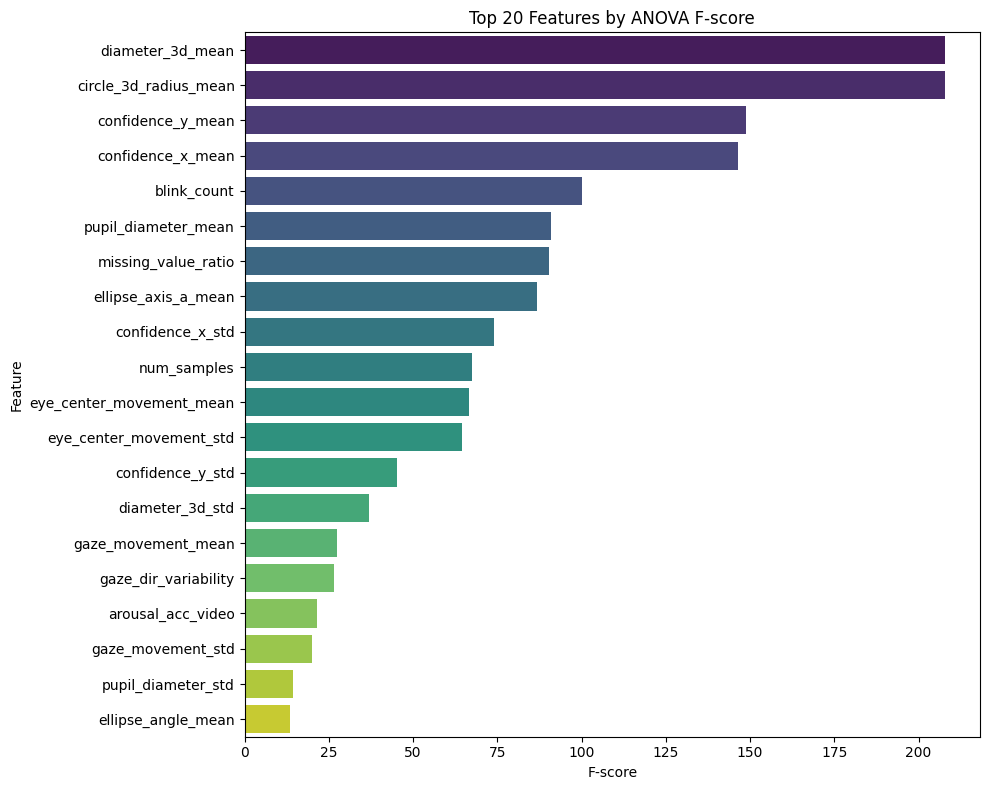

ANOVA F-score feature selection complete.
Number of features evaluated: 29
Top 5 features by F-score:
                  Feature     F_score       p_value
12       diameter_3d_mean  207.830450  6.806973e-45
14  circle_3d_radius_mean  207.830450  6.806973e-45
19      confidence_y_mean  148.813405  4.601539e-33
18      confidence_x_mean  146.344719  1.463406e-32
22            blink_count  100.220217  4.726373e-23


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_scores.sort_values(by="F_score", ascending=False).head(20),
    y="Feature", x="F_score", palette="viridis"
)
plt.title("Top 20 Features by ANOVA F-score")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# --- PRINT SUMMARY INFO ---
print("ANOVA F-score feature selection complete.")
print(f"Number of features evaluated: {feature_scores.shape[0]}")
print("Top 5 features by F-score:")

print(feature_scores.sort_values(by="F_score", ascending=False).head(5))



In [62]:
!pip install statsmodels


In [31]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Step 1: Drop the target column if still present
X_vif = X_train.copy()

# Step 2: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)

X_scaled_clean = X_scaled[~np.isnan(X_scaled).any(axis=1)]
X_scaled_clean = X_scaled_clean[~np.isinf(X_scaled_clean).any(axis=1)]


# Step 3: Compute VIF DataFrame
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns  # Make sure X_vif matches X_scaled_clean shape
vif_data['VIF'] = [variance_inflation_factor(X_scaled_clean, i) for i in range(X_scaled_clean.shape[1])]
# Step 4: Sort by VIF score
vif_data_sorted = vif_data.sort_values(by='VIF', ascending=False)

# Display
print(vif_data_sorted)


                     feature          VIF
12          diameter_3d_mean          inf
14     circle_3d_radius_mean          inf
19         confidence_y_mean  2783.845839
18         confidence_x_mean  2756.477459
4          75_percentile_GSR   918.615299
0                   GSR_mean   892.590099
2                    HR_mean    67.963974
5           75_percentile_HR    61.191589
23        gaze_movement_mean    27.120069
24         gaze_movement_std    26.856977
15       ellipse_axis_a_mean    11.996400
21          confidence_y_std    10.104919
10       pupil_diameter_mean     9.560055
27   eye_center_movement_std     9.425792
28       missing_value_ratio     8.052386
20          confidence_x_std     7.453121
9                num_samples     7.436054
26  eye_center_movement_mean     6.664972
1               GSR_variance     4.485377
22               blink_count     3.828789
17         ellipse_angle_std     2.505616
25      gaze_dir_variability     2.455618
3                HR_variance     2

/home/rounak/CODE/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


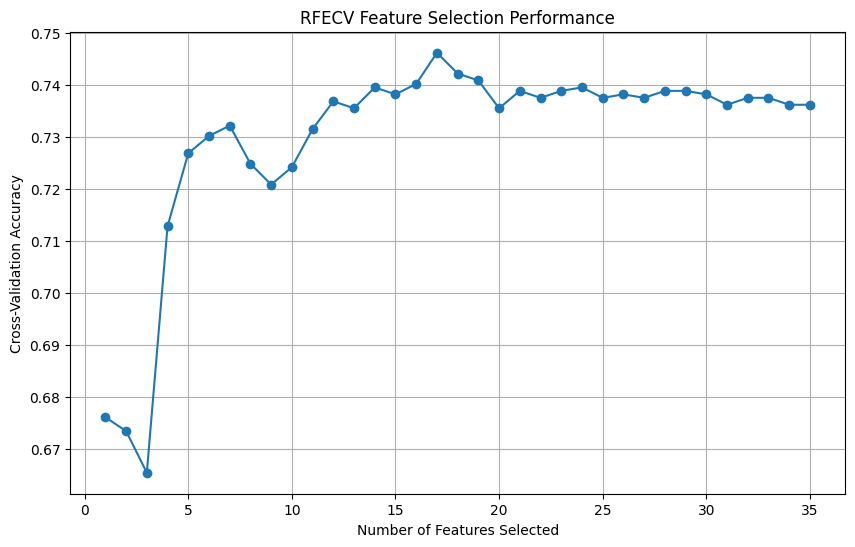

Optimal number of features: 17
Selected features:
['75_percentile_HR', 'arousal_acc_video', 'num_samples', 'diameter_3d_mean', 'diameter_3d_std', 'circle_3d_radius_mean', 'ellipse_axis_b_mean', 'ellipse_angle_mean', 'confidence_x_mean', 'confidence_y_mean', 'confidence_y_std', 'blink_count', 'gaze_movement_mean', 'gaze_movement_std', 'eye_center_movement_mean', 'eye_center_movement_std', 'missing_value_ratio']
RFECV feature selection complete.
Total features evaluated: 35
Number of features selected: 17
Top 10 selected features by ranking (if available):
                Feature  Ranking  Selected
5      75_percentile_HR        1      True
11    arousal_acc_video        1      True
13          num_samples        1      True
22   ellipse_angle_mean        1      True
21  ellipse_axis_b_mean        1      True
28          blink_count        1      True
29   gaze_movement_mean        1      True
30    gaze_movement_std        1      True
24    confidence_x_mean        1      True
25    con

In [65]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import pandas as pd

# Copy features (you can optionally drop high-VIF columns here)
X_rfe = X_train.copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_rfe_scaled = scaler.fit_transform(X_rfe)


# Define model
# model = LogisticRegression(max_iter=1000)
model = LogisticRegression(solver='saga', max_iter=5000)


# RFECV with 5-fold stratified CV
rfecv = RFECV(
    estimator=model,
    step=1,
    cv=StratifiedKFold(5),
    scoring='accuracy'
)

# Fit RFECV
rfecv.fit(X_rfe_scaled, y_train)

# Get selected features
selected_features = X_rfe.columns[rfecv.support_]

# Get rankings
ranking_df = pd.DataFrame({
    'Feature': X_rfe.columns,
    'Ranking': rfecv.ranking_,
    'Selected': rfecv.support_
}).sort_values(by='Ranking')

# Plot CV accuracy vs number of features
mean_test_scores = rfecv.cv_results_['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mean_test_scores) + 1), mean_test_scores, marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
plt.title("RFECV Feature Selection Performance")
plt.grid(True)
plt.show()

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected features:\n{selected_features.tolist()}")


# --- PRINT SUMMARY INFO ---
print("RFECV feature selection complete.")
print(f"Total features evaluated: {X_rfe.shape[1]}")
print(f"Number of features selected: {rfecv.n_features_}")
print("Top 10 selected features by ranking (if available):")

print(ranking_df[ranking_df['Selected']].head(10))

# Optional: show full ranking table (sorted)
# print("\nFull feature rankings:")
# print(ranking_df)




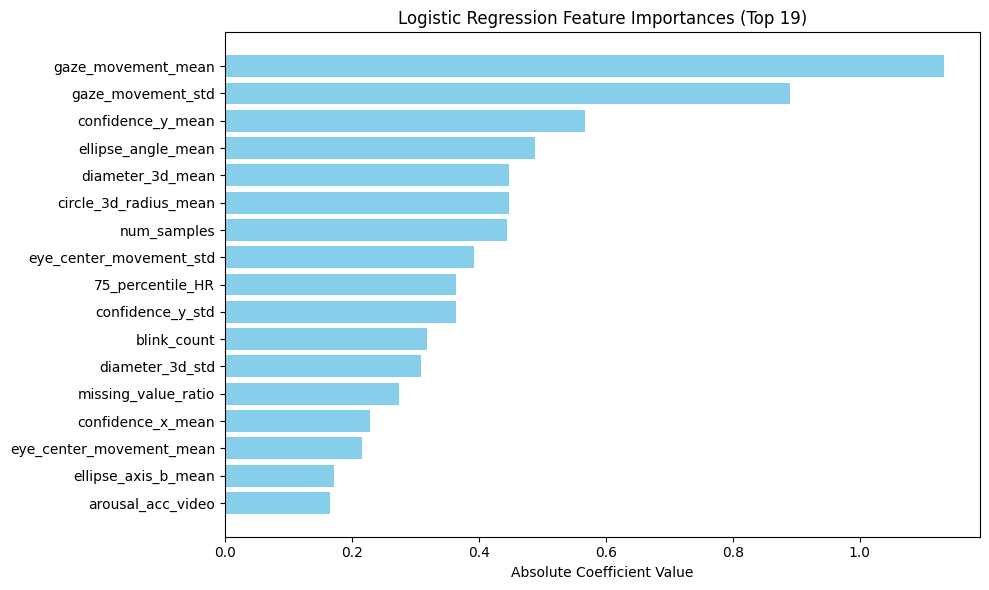

Logistic Regression coefficient analysis complete.
Number of selected features: 17
Top 19 features by absolute coefficient value:
                     Feature  Importance
12        gaze_movement_mean    1.132508
13         gaze_movement_std    0.889823
9          confidence_y_mean    0.566446
7         ellipse_angle_mean    0.487709
3           diameter_3d_mean    0.446759
5      circle_3d_radius_mean    0.446759
2                num_samples    0.444625
15   eye_center_movement_std    0.391442
0           75_percentile_HR    0.364160
10          confidence_y_std    0.363454
11               blink_count    0.317453
4            diameter_3d_std    0.308346
16       missing_value_ratio    0.273889
8          confidence_x_mean    0.229144
14  eye_center_movement_mean    0.216279
6        ellipse_axis_b_mean    0.171776
1          arousal_acc_video    0.166102


In [66]:
import numpy as np

# Get coefficients of the selected features
coefs = rfecv.estimator_.coef_.flatten()
selected_feature_names = X_rfe.columns[rfecv.support_]

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': np.abs(coefs)  # Use abs since sign is not as useful here
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Absolute Coefficient Value")
plt.title("Logistic Regression Feature Importances (Top 19)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# --- PRINT SUMMARY INFO ---
print("Logistic Regression coefficient analysis complete.")
print(f"Number of selected features: {len(selected_feature_names)}")
print("Top 19 features by absolute coefficient value:")

print(importance_df.head(19))


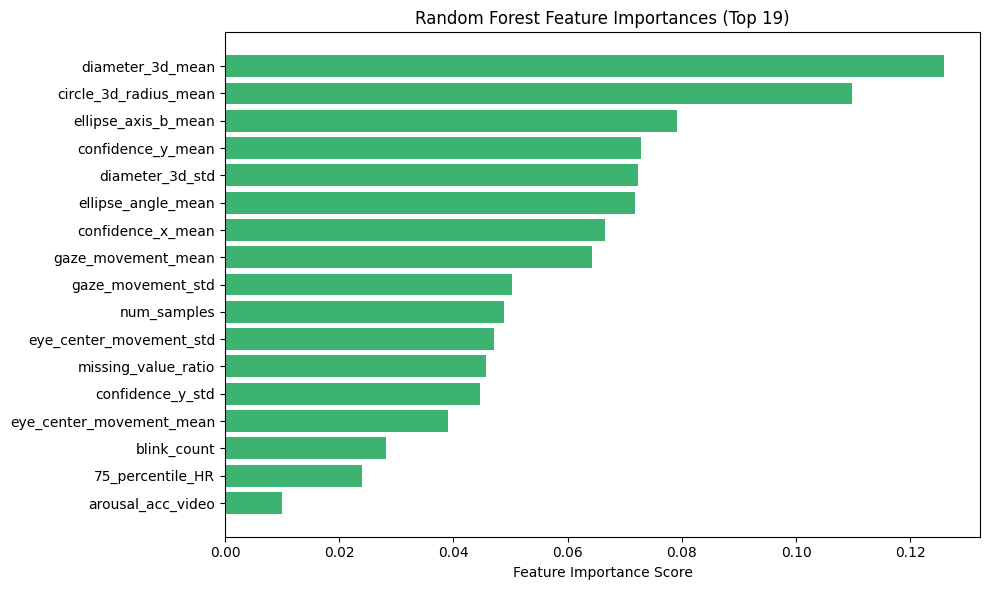

Random Forest feature importance analysis complete.
Number of selected features used: 17
Top 19 features by importance score:
                     Feature  Importance
3           diameter_3d_mean    0.125893
5      circle_3d_radius_mean    0.109797
6        ellipse_axis_b_mean    0.079120
9          confidence_y_mean    0.072751
4            diameter_3d_std    0.072259
7         ellipse_angle_mean    0.071831
8          confidence_x_mean    0.066607
12        gaze_movement_mean    0.064181
13         gaze_movement_std    0.050189
2                num_samples    0.048772
15   eye_center_movement_std    0.047165
16       missing_value_ratio    0.045613
10          confidence_y_std    0.044671
14  eye_center_movement_mean    0.038986
11               blink_count    0.028217
0           75_percentile_HR    0.023966
1          arousal_acc_video    0.009982


In [67]:
from sklearn.ensemble import RandomForestClassifier
importances = []

# Step 1: Filter selected features only
X_selected = X_rfe[selected_features]

# Step 2: Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_selected, y_train)

# Step 3: Get feature importances
rf_importance = rf_model.feature_importances_

# Step 4: Create DataFrame for plotting
rf_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_importance
}).sort_values(by='Importance', ascending=False)

# Step 5: Plot
plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='mediumseagreen')
plt.xlabel("Feature Importance Score")
plt.title("Random Forest Feature Importances (Top 19)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- PRINT SUMMARY INFO ---
print("Random Forest feature importance analysis complete.")
print(f"Number of selected features used: {len(selected_features)}")
print("Top 19 features by importance score:")

print(rf_importance_df.head(19))




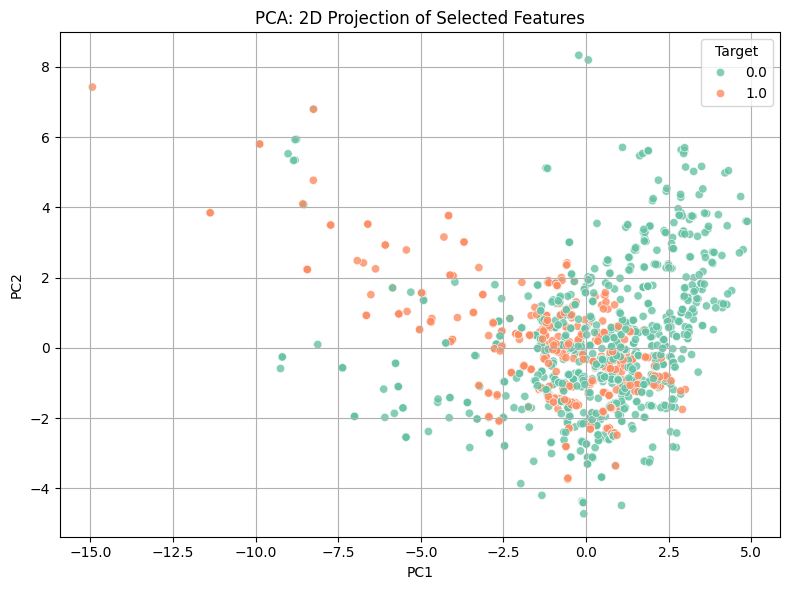

In [35]:
from sklearn.decomposition import PCA
import seaborn as sns

# Use only selected features
X_selected = X_rfe[selected_features]

# Standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Target': y_train.values  # assuming y_train is a Series
})

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Target', palette='Set2', alpha=0.8)
plt.title('PCA: 2D Projection of Selected Features')
plt.grid(True)
plt.tight_layout()
plt.show()


In [68]:
# --- PRINT SUMMARY INFO ---
explained_var = pca.explained_variance_ratio_
print("PCA on selected features complete.")
print(f"Explained variance by PC1: {explained_var[0]:.4f}")
print(f"Explained variance by PC2: {explained_var[1]:.4f}")
print(f"Total variance explained by first 2 PCs: {explained_var.sum():.4f}")


PCA on selected features complete.
Explained variance by PC1: 0.2961
Explained variance by PC2: 0.1664
Total variance explained by first 2 PCs: 0.4625
